In [2]:
from pathlib import Path
# import json
# import configparser
import pprint
pp = pprint.PrettyPrinter(indent=4);
import time
import math
from collections import namedtuple

# # pip install slicerio
# import slicerio.server

# # packages for 3d
# #   # for OCT 3D stuff and using in jupyter
# #   - trame-jupyter-extension
# #   - trame
# #   - trame-vtk
# #   - trame-vuetify
# #   - ipywidgets

import matplotlib.pyplot as plt
import plotly.express as px

# interactive panels
import panel as pn
pn.extension('plotly');

import numpy as np
import pandas as pd
import addict

import cv2
import skimage
import sklearn
import scipy.signal

import pyvista as pv
from PIL import Image
import SimpleITK as sitk

# with vedo
#from vedo import dataurl, Volume, Text2D
import vedo
vedo.settings.default_backend = 'vtk'
#from vedo.applications import Slicer3DPlotter
import naatos_oct_tools.plotters.vedo_plotters as vedo_plotters
import naatos_oct_tools.plotters.sitk_plotters as sitk_plotters

import naatos_oct_tools.thorlabs_oct_file_reading

In [3]:
%matplotlib inline

In [4]:
# Magics to autoreload submodules when they are modified
%load_ext autoreload
%autoreload 2

In [5]:
#%% Load OCT study information
#folder_octexport_root = Path(r'\\file.corp.ghlabs.org\Shared\Projects\NAATOS\V1\NAATOS_OCT_WORK\OCTExport')
folder_octexport_root = Path(r'D:\SGProjects\NAATOS\OCTlocal')
# this is also folder name


In [6]:
oct_scalar_min = 30;
oct_scalar_max = 60;
codename = '20250429';

#study_name = 'GHL_pyapp_20250326T1416'; # strip 14 day 1
#study_name = 'GHL_pyapp_20250327T1450'; # strip 14 day 2
#study_name = 'GHL_pyapp_20250326T1258'; # strip 7 day 1
#study_name = 'GHL_pyapp_20250327T1428'; # strip 7 day 2

study_name = 'GHL_pyapp_20250326T1403'; # oct study folder

In [7]:
octstudy = naatos_oct_tools.thorlabs_oct_file_reading.OCT_Study_Folder(study_name,folder_octexport_root);

STUDY: GHL_pyapp_20250326T1403
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 20,
    'study_num_vtk_files': 0}


In [8]:
octstudy.num_oct_files

20

In [9]:
octstudy

<OCT_Study_Folder Object>
GHL_pyapp_20250326T1403 in folder D:/SGProjects/NAATOS/OCTlocal
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 20,
    'study_num_vtk_files': 0}

# Read previously-saved Merged volume

In [10]:
fname_merged_and_rescaled_volume = octstudy.folder_study_processed/'{:s}_STACKED_RESCALED_{:}to{:}_uint8.vtk'.format(octstudy.name,oct_scalar_min,oct_scalar_max);
print(f'Loading {fname_merged_and_rescaled_volume.name}')
#vdvol = vedo.read(fname_merged_and_rescaled_volume);
vdvol = vedo.Volume(pv.read(fname_merged_and_rescaled_volume));
octstudy.vdvol = vdvol;
print(vdvol)

Loading GHL_pyapp_20250326T1403_STACKED_RESCALED_30to60_uint8.vtk
vedo.volume.Volume at (0x19578d04030)                                      
name          : Volume
dimensions    : [ 920 9000  350]
origin        : (0, 0, 0)
center        : (1.59676, 89.9900, 3.49000)
spacing       : (3.47500e-3, 0.0200000, 0.0200000)
bounds        : x=(0, 3.19), y=(0, 180), z=(0, 6.98)
memory size   : 2764 MB
scalar size   : 1 bytes (unsigned char)
scalar range  : (0.0, 255.0)


# Processing Step X - Cast In-Memory Views To SimpleITK Types

In [11]:
# Get ITK image without requiring new memory
import itk
import vtk

# create itk_image
itk_image = itk.image_from_vtk_image(vdvol.dataset)

# itk_image
print(itk_image)

Image (000001962B096110)
  RTTI typeinfo:   class itk::Image<unsigned char,3>
  Reference Count: 1
  Modified Time: 9
  Debug: Off
  Object Name: 
  Observers: 
    none
  Source: (none)
  Source output name: (none)
  Release Data: Off
  Data Released: False
  Global Release Data: Off
  PipelineMTime: 0
  UpdateMTime: 0
  RealTimeStamp: 0 seconds 
  LargestPossibleRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [920, 9000, 350]
  BufferedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [920, 9000, 350]
  RequestedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [920, 9000, 350]
  Spacing: [0.003475, 0.02, 0.02]
  Origin: [0, 0, 0]
  Direction: 
1 0 0
0 1 0
0 0 1

  IndexToPointMatrix: 
0.003475 0 0
0 0.02 0
0 0 0.02

  PointToIndexMatrix: 
287.77 0 0
0 50 0
0 0 50

  Inverse Direction: 
1 0 0
0 1 0
0 0 1

  PixelContainer: 
    ImportImageContainer (000001957943B270)
      RTTI typeinfo:   class itk::ImportImageContainer<unsigned __int64,unsigned char>
      Re

In [12]:
itk_image.GetImageDimension()

3

In [13]:
# make simpleitk image
def itkToSimpleITK(itk_image):
    new_sitk_image = sitk.GetImageFromArray(itk.GetArrayViewFromImage(itk_image),isVector=itk_image.GetNumberOfComponentsPerPixel()>1);
    new_sitk_image.SetOrigin(tuple(itk_image.GetOrigin()))
    new_sitk_image.SetSpacing(tuple(itk_image.GetSpacing()))
    new_sitk_image.SetDirection(itk.GetArrayFromMatrix(itk_image.GetDirection()).flatten()) 
    return new_sitk_image;
simgmerged = itkToSimpleITK(itk_image);

# Prepare To Extract Useful Information

In [14]:
data_extracted = addict.Addict();

# Processing Step 1 - Automatic Find Bounds Of Strip

In [15]:
size = simgmerged.GetSize()
print(simgmerged.GetSize())

(920, 9000, 350)


In [16]:
# Do Binary Threhsolding On Entire Volume Image
step1_binarythresholding_lo = 250;
step1_binarythresholding_hi = 255;
seg = sitk.BinaryThreshold(
    simgmerged, lowerThreshold=step1_binarythresholding_lo, upperThreshold=step1_binarythresholding_hi, insideValue=1, outsideValue=0
)


In [17]:
# Get numpy array view from simpleitk image (shares memory)
print(seg.GetSize())
nda = sitk.GetArrayViewFromImage(seg);
print(nda.shape)
# note the dimensions permute

(920, 9000, 350)
(350, 9000, 920)


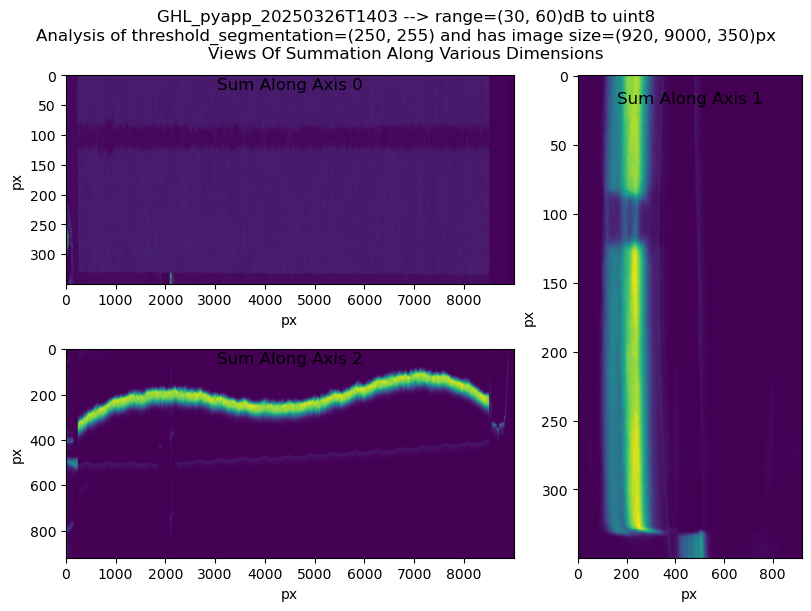

In [18]:
# Show 2d images of summation along each dimension
ndasum0 = nda.sum(axis=0)
ndasum1 = nda.sum(axis=1)
ndasum2 = nda.sum(axis=2)

fig = plt.figure(figsize=(8,6),constrained_layout=True);
fig.suptitle(
"""{:s} --> range={:s}dB to uint8
Analysis of threshold_segmentation={:s} and has image size={:s}px
Views Of Summation Along Various Dimensions""" \
    .format(
        octstudy.name,
        str((oct_scalar_min,oct_scalar_max)),
        str((step1_binarythresholding_lo,step1_binarythresholding_hi)),
        str(seg.GetSize())
    )
)
gs = fig.add_gridspec(2,3);

fig_ax1 = fig.add_subplot(gs[0,0:2]);
fig_ax1.set_title('Sum Along Axis 0',y=0.95,verticalalignment='top');
fig_ax1.imshow(ndasum2,aspect='auto');
fig_ax1.set_xlabel('px');
fig_ax1.set_ylabel('px');

fig_ax2 = fig.add_subplot(gs[:,2]);
fig_ax2.set_title('Sum Along Axis 1',y=0.95,verticalalignment='top');
fig_ax2.imshow(ndasum1,aspect='auto');
fig_ax2.set_xlabel('px');
fig_ax2.set_ylabel('px');

fig_ax3 = fig.add_subplot(gs[1,0:2]);
fig_ax3.set_title('Sum Along Axis 2',y=0.95,verticalalignment='top');
fig_ax3.imshow(ndasum0.T,aspect='auto');
fig_ax3.set_xlabel('px');
fig_ax3.set_ylabel('px');

fig.savefig(octstudy.folder_study_processed/'processing_step1a_{:s}.jpg'.format(time.strftime('%Y%m%d')))

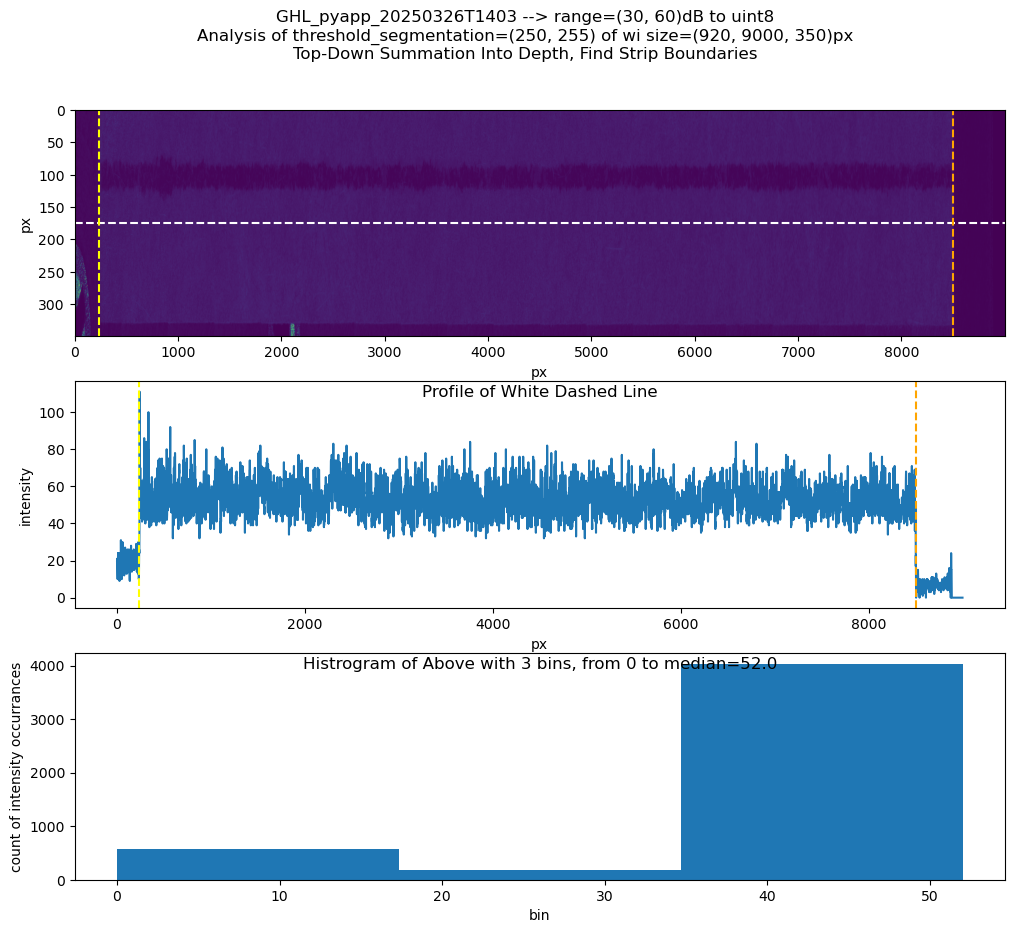

In [19]:
# Do Automatic Analysis Using Line Down the Middle Of Strip
fig,ax = plt.subplots(3,1,figsize=(12,10),squeeze=False);
fig.suptitle(
"""{:s} --> range={:s}dB to uint8
Analysis of threshold_segmentation={:s} of wi size={:s}px
Top-Down Summation Into Depth, Find Strip Boundaries""" \
    .format(
        octstudy.name,
        str((oct_scalar_min,oct_scalar_max)),
        str((step1_binarythresholding_lo,step1_binarythresholding_hi)),
        str(seg.GetSize())
    )
)

ndasum2 = nda.sum(axis=2);
ax[0,0].imshow(ndasum2,aspect='auto');
ax[0,0].axhline(ndasum2.shape[0]//2,color='white',linestyle='dashed')
ax[0,0].set_xlabel('px')
ax[0,0].set_ylabel('px')

ax[1,0].set_title('Profile of White Dashed Line',y=0.95,verticalalignment='top')
a_whiteline = ndasum2[ndasum2.shape[0]//2,:].copy();
ax[1,0].plot(a_whiteline);
ax[1,0].set_xlabel('px')
ax[1,0].set_ylabel('intensity')

# bin histogram along white line, into 3 bins, with the median being the upper range
median = np.median(a_whiteline)
ax[2,0].set_title('Histrogram of Above with 3 bins, from 0 to median={:}'.format(median),y=0.95,verticalalignment='top')
histret,histedges,_ = ax[2,0].hist(a_whiteline,bins=3,range=(0,median))
ax[2,0].set_xlabel('bin')
ax[2,0].set_ylabel('count of intensity occurrances')

# take the value in middle of 2nd bin
threshold_value = (histedges[2]+histedges[1])/2;

# look for sharp edges transitioning where these bins occur
a_whiteline[a_whiteline<threshold_value] = 0
a_whiteline[a_whiteline>=threshold_value] = 1
transition_edges = np.where(a_whiteline[:-1] != a_whiteline[1:])[0]
# for right edge, start at middle and find right-most
edge_right = transition_edges[transition_edges>(ndasum2.shape[1]//2)][0];
edge_left = transition_edges[transition_edges<=(ndasum2.shape[1]//2)][-1];

ax[0,0].axvline(edge_left,color='yellow',linestyle='dashed')
ax[0,0].axvline(edge_right,color='orange',linestyle='dashed')
ax[1,0].axvline(edge_left,color='yellow',linestyle='dashed')
ax[1,0].axvline(edge_right,color='orange',linestyle='dashed')

# store useful information
data_extracted['auto_bounds']['topdown_edge_left_px'] = edge_left.item();
data_extracted['auto_bounds']['topdown_edge_right_px'] = edge_right.item();

# save figure
fig.savefig(octstudy.folder_study_processed/'processing_step1b_{:s}.jpg'.format(time.strftime('%Y%m%d')))

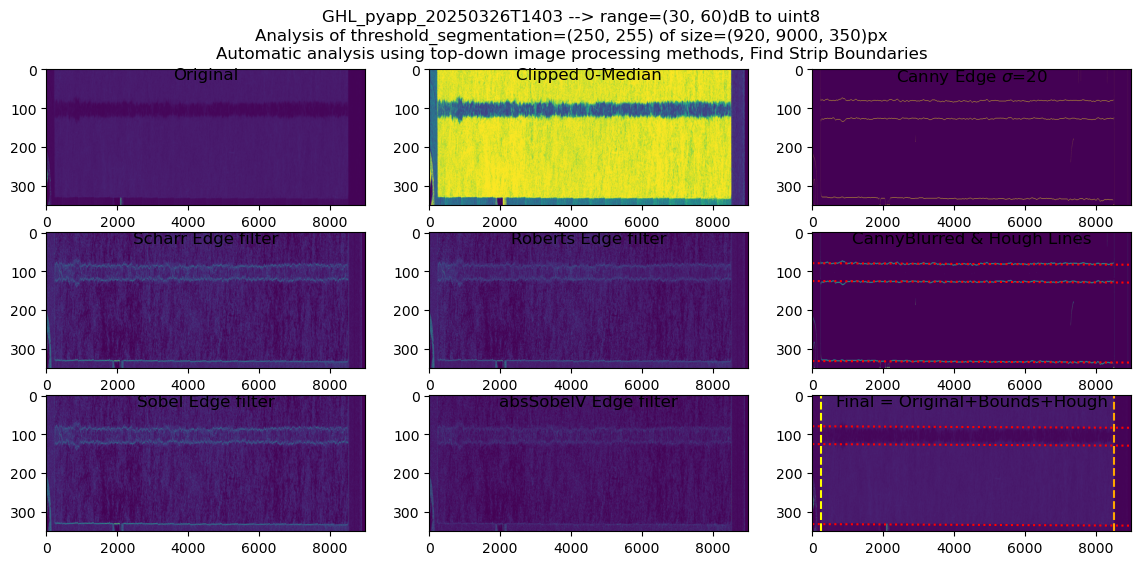

In [20]:
# Do automatic analysis using top-down image processing methods

fig,ax = plt.subplots(3,3,figsize=(14,6),squeeze=False);

fig.suptitle(
"""{:s} --> range={:s}dB to uint8
Analysis of threshold_segmentation={:s} of size={:s}px
Automatic analysis using top-down image processing methods, Find Strip Boundaries""" \
    .format(
        octstudy.name,
        str((oct_scalar_min,oct_scalar_max)),
        str((step1_binarythresholding_lo,step1_binarythresholding_hi)),
        str(seg.GetSize())
    )
)

#image = ndasum2[:,edge_left:edge_right];
image = ndasum2

ax[0,0].set_title('Original',y=0.95,verticalalignment='top')
ax[0,0].imshow(image,aspect='auto')

ax[0,1].set_title('Clipped 0-Median',y=0.95,verticalalignment='top')
image2 = np.clip(image,a_min=0,a_max=median)
ax[0,1].imshow(image2,aspect='auto')

ax[1,0].set_title('Scharr Edge filter',y=0.95,verticalalignment='top')
edge_scharr = skimage.filters.scharr(image2);
ax[1,0].imshow(edge_scharr,aspect='auto')

ax[1,1].set_title('Roberts Edge filter',y=0.95,verticalalignment='top')
edge_roberts = skimage.filters.roberts(image2);
ax[1,1].imshow(edge_roberts,aspect='auto')

ax[2,0].set_title('Sobel Edge filter',y=0.95,verticalalignment='top')
edge_sobel = skimage.filters.sobel(image2);
ax[2,0].imshow(edge_sobel,aspect='auto')

ax[2,1].set_title('absSobelV Edge filter',y=0.95,verticalalignment='top')
edge_sobelv = skimage.filters.sobel_v(image2);
ax[2,1].imshow(abs(edge_sobelv),aspect='auto')

ax[0,2].set_title(r'Canny Edge $\sigma$=20',y=0.95,verticalalignment='top')
edge_canny = skimage.feature.canny(image2,sigma=20,low_threshold=0.45,high_threshold=0.55)
ax[0,2].imshow(edge_canny.view(dtype=np.uint8),aspect='auto')


# contours = skimage.measure.find_contours(edge_canny.view(dtype=np.uint8),level=0.5)
# for contour in contours:
#     ax[1,2].plot(contour[:, 1], contour[:, 0], linewidth=2)
# ax[1,2].yaxis.set_inverted(True)

# -- find some boundaries on topdown view using image processing methods
# houghline finding
ax[1,2].set_title(r'CannyBlurred & Hough Lines',y=0.95,verticalalignment='top')
img_blured_edges = cv2.blur(edge_canny.view(dtype=np.uint8)*255,(3,3));
ax[1,2].imshow(img_blured_edges,aspect='auto')

# Straight-line Hough transform
# Set a precision of Scan a 10 degree angle off the normal (this seems to be 90 degrees with this skimage implementation for horizontal-like lines) with resolution of 0.05 degrees.
tested_angles = np.linspace(math.radians(90-10),math.radians(90+10),int( (math.radians(10)*2)/math.radians(0.05) ), endpoint=True)
h, theta, d = skimage.transform.hough_line(img_blured_edges, theta=tested_angles)
hough_line_data = skimage.transform.hough_line_peaks(h, theta, d);
for _, angle, dist in zip(*hough_line_data):
    (x0, y0) = dist * np.array([np.cos(angle), np.sin(angle)])
    ax[1,2].axline((x0, y0), slope=np.tan(angle + np.pi / 2), color='red',linestyle='dotted')

# Calculate a boundary from sum along strip width
along_strip_sum=ndasum2.sum(axis=0);
along_strip_sum_derivative = scipy.signal.savgol_filter(along_strip_sum,window_length=32,polyorder=3,deriv=1)
edge_topdown_left2 = np.argmax(along_strip_sum_derivative);
edge_topdown_right2 = np.argmin(along_strip_sum_derivative);
ax[2,2].set_title(r'Final = Original+Bounds+Hough',y=0.95,verticalalignment='top')
ax[2,2].imshow(image,aspect='auto');
ax[2,2].axvline(edge_topdown_left2,color='yellow',linestyle='--')
ax[2,2].axvline(edge_topdown_right2,color='orange',linestyle='--')
for _, angle, dist in zip(*hough_line_data):
    (x0, y0) = dist * np.array([np.cos(angle), np.sin(angle)])
    ax[2,2].axline((x0, y0), slope=np.tan(angle + np.pi / 2), color='red',linestyle='dotted')

# Extract relevant data
data_extracted['auto_bounds']['topdown_edge_left_px2'] = edge_topdown_left2.item()+5; # move in just a bit
data_extracted['auto_bounds']['topdown_edge_right_px2'] = edge_topdown_right2.item()-5; # move in just a bit
data_extracted['auto_topdown_houghline'] = hough_line_data;

# Save to processed folder
fig.savefig(octstudy.folder_study_processed/'processing_step1c_{:s}.jpg'.format(time.strftime('%Y%m%d')))

(array([ 36, 242, 480, 500, 742, 756, 778, 822, 842, 848, 858, 864, 874,
       878]), {'peak_heights': array([1.74220237e+08, 5.35633091e+08, 1.46069271e+08, 1.46773415e+08,
       5.70977090e+07, 5.63516180e+07, 5.52994560e+07, 5.25881950e+07,
       5.15675850e+07, 5.12891010e+07, 5.08646870e+07, 5.07105010e+07,
       5.04241400e+07, 5.02789910e+07]), 'prominences': array([5.91110920e+07, 4.97748845e+08, 4.01907000e+05, 1.11309700e+06,
       2.55090000e+04, 1.99240000e+04, 3.49290000e+04, 2.53470000e+04,
       4.61780000e+04, 1.65710000e+04, 3.18200000e+04, 1.62330000e+04,
       6.50530000e+04, 2.08380000e+04]), 'left_bases': array([  0,   0, 474, 486, 741, 755, 777, 821, 841, 847, 857, 863, 872,
       877]), 'right_bases': array([ 84, 918, 486, 918, 918, 918, 918, 918, 918, 918, 918, 918, 918,
       918])})
(array([ 36.9281601 , 185.30072198,   5.70720741,   8.83007213,
         0.68357345,   0.63432936,   0.68099991,   0.71177562,
         0.84023459,   0.60522873,   1.22958

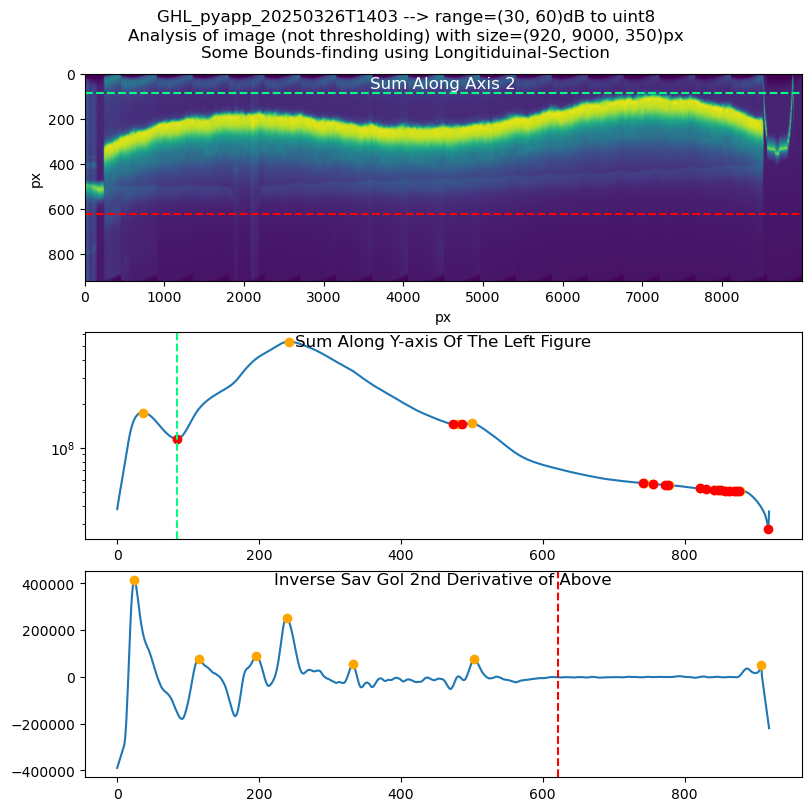

In [21]:
# Do automatic analysis using Longitiduinal-Section

ndasum0 = sitk.GetArrayViewFromImage(simgmerged).sum(axis=0)
#ndasum1 = nda.sum(axis=1)
#ndasum2 = nda.sum(axis=2)

fig = plt.figure(figsize=(8,8),constrained_layout=True);
fig.suptitle(
"""{:s} --> range={:s}dB to uint8
Analysis of image (not thresholding) with size={:s}px
Some Bounds-finding using Longitiduinal-Section""" \
    .format(
        octstudy.name,
        str((oct_scalar_min,oct_scalar_max)),
        str(seg.GetSize())
    )
)
gs = fig.add_gridspec(3,1);

# fig_ax1 = fig.add_subplot(gs[0,0:2]);
# fig_ax1.set_title('Sum Along Axis 0',y=0.95,verticalalignment='top')
# fig_ax1.imshow(ndasum2,aspect='auto');
# fig_ax1.set_xlabel('px');
# fig_ax1.set_ylabel('px');

# fig_ax2 = fig.add_subplot(gs[:,2]);
# fig_ax2.set_title('Sum Along Axis 1',y=0.95,verticalalignment='top')
# fig_ax2.imshow(ndasum1,aspect='auto');
# fig_ax2.set_xlabel('px');
# fig_ax2.set_ylabel('px');

fig_ax1 = fig.add_subplot(gs[0,0]);
fig_ax1.set_title('Sum Along Axis 2',y=0.95,verticalalignment='top',color='white');
fig_ax1.imshow(ndasum0.T,aspect='auto');
fig_ax1.set_xlabel('px');
fig_ax1.set_ylabel('px');

nda_sum_curve = ndasum0.sum(axis=0)
pks = scipy.signal.find_peaks(nda_sum_curve,prominence=10000,height=10000)
widths = scipy.signal.peak_widths(nda_sum_curve,pks[0])
localmin = scipy.signal.argrelextrema(nda_sum_curve, np.less)[0]
print(pks)
print(widths)
print(localmin)
tallest_peak = np.argmax(pks[1]['peak_heights'])


# look for top edge
data_extracted['auto_bounds']['thickness_depth_top_px'] = localmin[localmin<pks[0][tallest_peak]][-1].item();


fig_ax2 = fig.add_subplot(gs[1,0]);
fig_ax2.set_title('Sum Along Y-axis Of The Left Figure',y=0.95,verticalalignment='top');
fig_ax2.plot(nda_sum_curve);
fig_ax2.plot(pks[0],nda_sum_curve[pks[0]],marker='o',linestyle='',color='orange');
fig_ax2.plot(localmin,nda_sum_curve[localmin],marker='o',linestyle='',color='red');
fig_ax2.set_yscale('log')



# mark top edge
fig_ax1.axhline( data_extracted['auto_bounds']['thickness_depth_top_px'] ,linestyle='dashed',color='springgreen')
fig_ax2.axvline( data_extracted['auto_bounds']['thickness_depth_top_px'] ,linestyle='dashed',color='springgreen')




savgol_of_sum_surve = scipy.signal.savgol_filter(nda_sum_curve,21,polyorder=3,deriv=2);
pks2 = scipy.signal.find_peaks(-savgol_of_sum_surve,prominence=50000)
print('pks2',pks2);
fig_ax3 = fig.add_subplot(gs[2,0]);
fig_ax3.set_title('Inverse Sav Gol 2nd Derivative of Above',y=0.95,verticalalignment='top');
fig_ax3.plot(-savgol_of_sum_surve);
fig_ax3.plot(pks2[0],-savgol_of_sum_surve[pks2[0]],marker='o',linestyle='',color='orange');

# look for bottom edge
#data_extracted['auto_bounds']['thickness_depth_bot_px'] = pks2[0][pks2[0] > max(pks[0])][1]
if pks2[0][pks2[0] > max(pks[0])].shape[0]>=2:
    print('more than 2')
    data_extracted['auto_bounds']['thickness_depth_bot_px'] = pks2[0][pks2[0] > max(pks[0])][1]
elif pks2[0][pks2[0] > max(pks[0])].shape[0]==1:
    print('had 1')
    data_extracted['auto_bounds']['thickness_depth_bot_px'] = ((pks[0][pks[0] > (pks2[0][-2])][0]) + (pks2[0][-2]))//2
fig_ax1.axhline( data_extracted['auto_bounds']['thickness_depth_bot_px'] ,linestyle='dashed',color='red')
fig_ax3.axvline( data_extracted['auto_bounds']['thickness_depth_bot_px'] ,linestyle='dashed',color='red')

# Save to processed folder
fig.savefig(octstudy.folder_study_processed/'processing_step1d_{:s}.jpg'.format(time.strftime('%Y%m%d')))

In [22]:
pp.pprint(data_extracted)

{   'auto_bounds': {   'thickness_depth_bot_px': np.int64(622),
                       'thickness_depth_top_px': 84,
                       'topdown_edge_left_px': 237,
                       'topdown_edge_left_px2': 243,
                       'topdown_edge_right_px': 8501,
                       'topdown_edge_right_px2': 8496},
    'auto_topdown_houghline': (   array([6146, 5537, 5217], dtype=uint64),
                                  array([1.57123375, 1.57123375, 1.57123375]),
                                  array([331., 125.,  79.]))}


# Processing Step 2 - Now Could We Save A Smaller Cropped File? Yes

In [23]:
print( 'Original',simgmerged.GetSize() )
slicer_0 = slice( data_extracted['auto_bounds']['thickness_depth_top_px']  ,  data_extracted['auto_bounds']['thickness_depth_bot_px']  )
slicer_1 = slice( data_extracted['auto_bounds']['topdown_edge_left_px2']  ,  data_extracted['auto_bounds']['topdown_edge_right_px2']  )
cropped_simple_itk_image = simgmerged[ slicer_0, slicer_1, :]
simgmerged_longcropped = simgmerged[ : , slicer_1, :]
print( 'Cropped Simple ITK Image',cropped_simple_itk_image.GetSize() )
print( 'Long-cropped Simple ITK Image',simgmerged_longcropped.GetSize() )
if False:
    # save this byte-adjusted volume
    fname = octstudy.folder_study_processed/'{:s}_STACKED_CROPPED_RESCALED_{:}to{:}_uint8.vtk'.format(octstudy.name,oct_scalar_min,oct_scalar_max);
    #vdvol.dataset.save()
    if(fname.exists()):
        print('Stacked volume byte-size .vtk file already exists, will not recreate.');
    else:
        #mergedvol.save(fname);
        sitkwriter = sitk.ImageFileWriter();
        sitkwriter.SetFileName(fname.as_posix())
        sitkwriter.Execute(cropped_simple_itk_image)

Original (920, 9000, 350)
Cropped Simple ITK Image (538, 8253, 350)
Long-cropped Simple ITK Image (920, 8253, 350)


# Processing Step 3 - Along Strip Analysis A

In [24]:
# Use the automatically determined boundaries along the strip to restrict the depth
# The automatically determined boundaries are too lenient, and initial cross-sections looks funny
#seg_sliced = seg[:,data_extracted['auto_bounds']['topdown_edge_left_px2']:data_extracted['auto_bounds']['topdown_edge_right_px2'],:]
seg_sliced = seg[:,slicer_1,:];

seg_sliced.GetSize()

(920, 8253, 350)

In [25]:
# Prepare a temporary location to store images as we go through each slice
folder_figure_temp = Path(f'C:\\TEMP\\OCTtmp\\{octstudy.name}');
folder_figure_temp.mkdir(parents=True,exist_ok=True);

timing 0.0006
timing 4.9936
(350, 10, 920)
timing 9.602
timing 12.3761
(   array([5537, 5217], dtype=uint64),
    array([1.57123375, 1.57123375]),
    array([125.,  79.]))
Angles: [np.float64(1.5712337526725895), np.float64(1.5712337526725895)]
XY: [(5537, 125.0), (5217, 79.0)]
Point on line (5217, 79.0)
Line is y=0.0004374259055920157 * x + 76.71794905052646
test for slice= 10
y is at 76.72232330958238
Point on line (5537, 125.0)
Line is y=0.0004374259055920157 * x + 122.57797276073701
test for slice= 10
y is at 122.58234701979293
Slice of the sum: slice(61, 137, None)
Step2pks (array([328]), {'peak_heights': array([61.4]), 'prominences': array([61.4]), 'left_bases': array([274]), 'right_bases': array([433]), 'widths': array([39.54605263]), 'width_heights': array([30.7]), 'left_ips': array([313.57894737]), 'right_ips': array([353.125])})
pks1 (array([304, 306, 313, 327, 340, 385]), {'peak_heights': array([0.1098101 , 0.10719784, 0.102746  , 0.42804244, 0.15294065,
       0.11880294]),

({'px_wax_transverse_edge_search_houghlines': (76, 122),
  'pixel_depth_strip_top_sum_threshold': 2,
  'pixel_depth_strip_top': 274,
  'pixel_depth_strip_bot': 433,
  'pixel_depth_wax_center': np.int64(385),
  'px_wax_transverse_edges': (83.3391304347826, 125.40983606557377),
  'wax_top_seed_candidate_px': (333, 104),
  'pksA': (array([ 54,  98, 136, 385]),
   {'prominences': array([9183.,  329., 1910.,  104.]),
    'left_bases': array([  1,  79,  79, 369]),
    'right_bases': array([159, 110, 159, 401]),
    'widths': array([21.12319991,  2.61288279, 17.27429611, 11.        ]),
    'width_heights': array([4591.5,  957.5, 1492. ,   52. ]),
    'left_ips': array([ 41.7371134 ,  96.31127451, 127.23026316, 381.        ]),
    'right_ips': array([ 62.86031332,  98.9241573 , 144.50455927, 392.        ])}),
  'pksB': (array([ 54, 137, 228]),
   {'prominences': array([8907., 2084.,  388.]),
    'left_bases': array([  2, 102, 204]),
    'right_bases': array([544, 544, 544]),
    'widths': arra

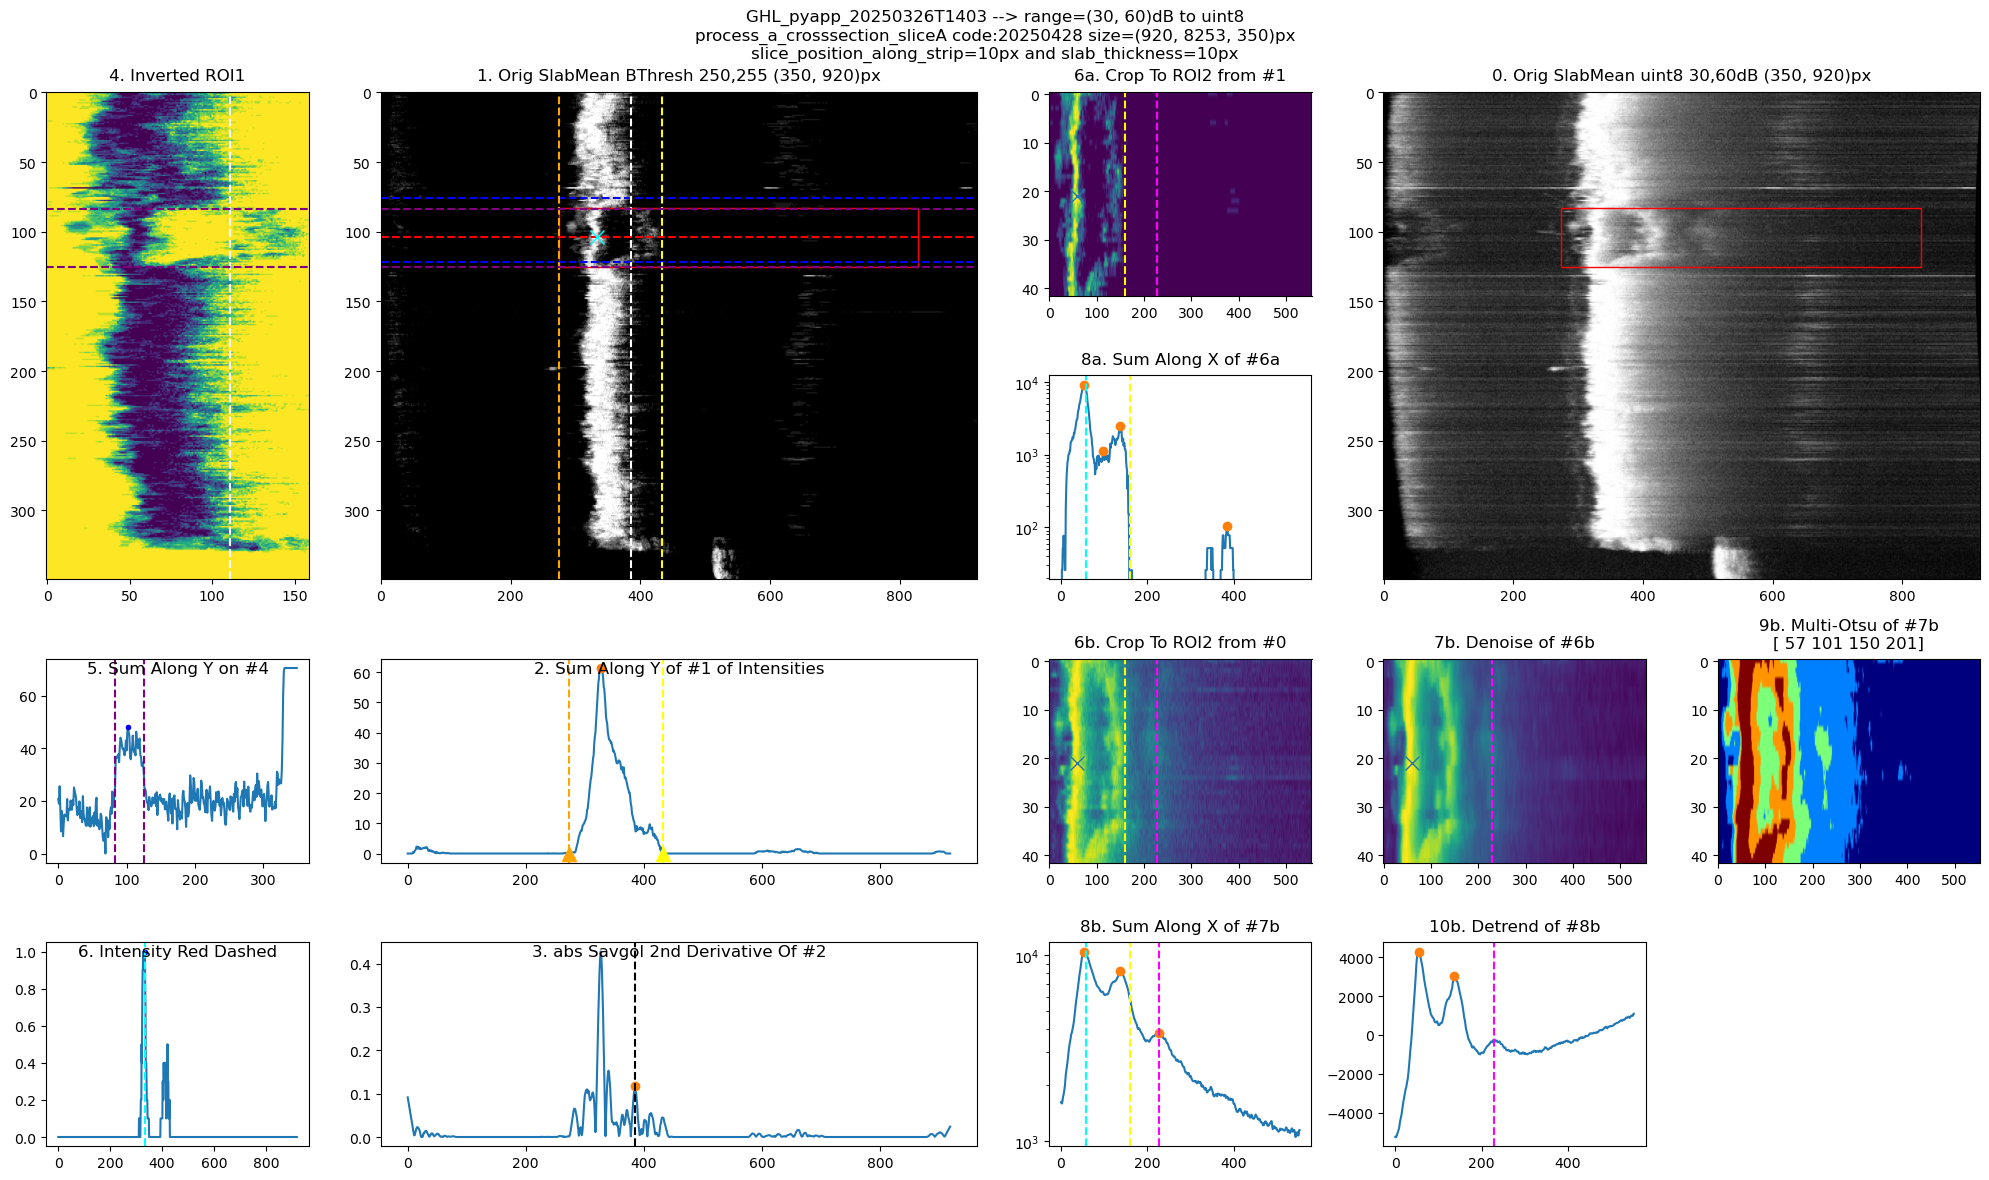

In [70]:
import matplotlib.patches
def process_a_crosssection_sliceA(seg : sitk.Image, slab_thickness_px,slice_position_along_strip_px, mkplot=True):
    slab_thickness = slab_thickness_px;
    sliceinfo = {};
    timestart = time.monotonic_ns();


    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    if(slab_thickness>1):
        seg_subset = seg[:,slice_position_along_strip_px-slab_thickness//2:slice_position_along_strip_px+slab_thickness//2,:]
        img_subset = simgmerged_longcropped[:,slice_position_along_strip_px-slab_thickness//2:slice_position_along_strip_px+slab_thickness//2,:]
    else:
        seg_subset = seg[:,slice_position_along_strip_px:slice_position_along_strip_px+1,:]
        img_subset = simgmerged_longcropped[:,slice_position_along_strip_px:slice_position_along_strip_px+1,:]
    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    nda = sitk.GetArrayFromImage(seg_subset);
    print(nda.shape)
    nda_mean = np.mean(nda,axis=1);
    print('timing',(time.monotonic_ns()-timestart)*1e-6)

    orignda = sitk.GetArrayViewFromImage(img_subset);
    orignda_mean = np.mean(orignda,axis=1);
    print('timing',(time.monotonic_ns()-timestart)*1e-6)



    if mkplot:
        #fig,ax = plt.subplots(3,2,figsize=(20,12));
        fig = plt.figure(figsize=(20,12));
        gs = fig.add_gridspec(4,6);
        fig.suptitle('{:s} --> range={:s}dB to uint8\nprocess_a_crosssection_sliceA code:20250428 size={:s}px\nslice_position_along_strip={:.0f}px and slab_thickness={:.0f}px'.format(octstudy.name,str((oct_scalar_min,oct_scalar_max)),str(seg.GetSize()),slice_position_along_strip_px,slab_thickness_px))


    # SHOW FULL IMAGES
    if mkplot:
        ax = fig.add_subplot(gs[0:2,1:3]);
        ax.set_title('1. Orig SlabMean BThresh {:},{:} {:s}px'.format(step1_binarythresholding_lo,step1_binarythresholding_hi,str(orignda_mean.shape)),y=1.0,verticalalignment='bottom')
        ax.imshow(nda_mean,aspect='auto',cmap='grey');
        ax_gray_img_binarythresh = ax;
    
        ax = fig.add_subplot(gs[0:2,4:6]);
        ax.set_title('0. Orig SlabMean uint8 {:},{:}dB {:s}px'.format(oct_scalar_min,oct_scalar_max,str(orignda_mean.shape)),y=1.0,verticalalignment='bottom')
        ax.imshow(orignda_mean,aspect='auto',cmap='grey');
        ax_gray_img_orig = ax;
    
    # FROM PREVIOUSLY CALCULATED HOUGH-LINES, FIND POSITIONS
    distances_of_houghlines_from_bottom = data_extracted['auto_topdown_houghline'][2]-seg.GetSize()[2]
    max_distance_from_bottom = 50;
    houghline_indexes = abs(distances_of_houghlines_from_bottom)>max_distance_from_bottom
    #seg.GetSize()
    houghline_indexes
    houghlines_selected = (
        data_extracted['auto_topdown_houghline'][0][houghline_indexes],
        data_extracted['auto_topdown_houghline'][1][houghline_indexes],
        data_extracted['auto_topdown_houghline'][2][houghline_indexes]
    )
    pp.pprint(houghlines_selected)
    angles = [ x for x in houghlines_selected[1] ];
    print('Angles:',angles)
    pts = [ (x.item(),y.item()) for x,y in zip(houghlines_selected[0],houghlines_selected[2]) ];
    print('XY:',pts)

    def get_ypoint_from_houghline(pt, angle, slice_pos_along_strip):
        #slice_pos_along_strip = 5610
        slope_m = np.tan(angle+np.pi/2);

        print('Point on line',pt);
        line_b = pt[1]-(slope_m*pt[0])
        print('Line is y={:} * x + {:}'.format(slope_m,line_b))

        print('test for slice=',slice_pos_along_strip)
        #y0 = slope_m * slice_pos_along_strip + line_b;
        y0 = slope_m * slice_pos_along_strip + line_b;
        print('y is at',y0)
        return y0
    #get_ypoint_from_houghline(pts[0],angles[0],5610)
    sliceinfo['px_wax_transverse_edge_search_houghlines'] = (
        int(get_ypoint_from_houghline(pts[1],angles[1],slice_position_along_strip_px).item()),
        int(get_ypoint_from_houghline(pts[0],angles[0],slice_position_along_strip_px).item()),
    )
    ax_gray_img_binarythresh.axhline(sliceinfo['px_wax_transverse_edge_search_houghlines'][0],linestyle='--',color='blue');
    ax_gray_img_binarythresh.axhline(sliceinfo['px_wax_transverse_edge_search_houghlines'][1],linestyle='--',color='blue');



    # SHOW STEP 2- SUM OF BINARY THRESHOLDED WHOLE-IMAGE
    slice_sum_of_1 = slice( sliceinfo['px_wax_transverse_edge_search_houghlines'][0]-15, sliceinfo['px_wax_transverse_edge_search_houghlines'][1]+15 )
    print('Slice of the sum:',slice_sum_of_1)
    nda_mean_sum = np.sum(nda_mean[slice_sum_of_1,:],axis=0);
    pks = scipy.signal.find_peaks(nda_mean_sum,width=10,height=10,prominence=0.001)
    print('Step2pks',pks);
    if mkplot:
        ax = fig.add_subplot(gs[2,1:3])
        ax.set_title('2. Sum Along Y of #1 of Intensities',y=0.95,verticalalignment='top')
        ax.plot(nda_mean_sum);
        ax.plot(pks[0],nda_mean_sum[pks[0]],'o',linestyle='');
    
    pixel_depth_strip_top_sum_threshold = 2;
    #pixel_depth_strip_top = np.nonzero(nda_mean_sum>pixel_depth_strip_top_sum_threshold)[0][0];
    #pixel_depth_strip_bot = np.nonzero(nda_mean_sum>pixel_depth_strip_top_sum_threshold)[0][-1];
    pixel_depth_strip_top = pks[1]['left_bases'][0];
    pixel_depth_strip_bot = pks[1]['right_bases'][0];

    if mkplot:
        #ax[1,1].set_title('Depth-Mean And X-Sum Vs Y',y=0.95,verticalalignment='top')
        ax.plot(pixel_depth_strip_top, nda_mean_sum[pixel_depth_strip_top] , marker='^', markersize=10,color='orange');
        ax.axvline(pixel_depth_strip_top,linestyle='--',color='orange');
        ax.plot(pixel_depth_strip_bot, nda_mean_sum[pixel_depth_strip_bot] , marker='^', markersize=10,color='yellow');
        ax.axvline(pixel_depth_strip_bot,linestyle='--',color='yellow');
        
        ax_gray_img_binarythresh.axvline(pixel_depth_strip_top,linestyle='--',color='orange');
        ax_gray_img_binarythresh.axvline(pixel_depth_strip_bot,linestyle='--',color='yellow');


    # SHOW STEP 3 - Savgol of #2
    nda_mean_sum_curvature = scipy.signal.savgol_filter(nda_mean_sum,21,polyorder=3,deriv=2);
    pks = scipy.signal.find_peaks(abs(nda_mean_sum_curvature),height=0.1,prominence=0)
    # restrict peaks to be right of the white line
    pksculled=pks[0][ pks[0]> round( (pixel_depth_strip_bot-pixel_depth_strip_top)/2 + pixel_depth_strip_top ) ] # halfway between orange and yellow
    widths = scipy.signal.peak_widths(abs(nda_mean_sum_curvature),pksculled,rel_height=0.5)
    print('pks1',pks)
    print('widths1',widths)
    if mkplot:
        #ax[2,1].plot(np.diff(nda_mean_sum,1));
        ax = fig.add_subplot(gs[3,1:3]);
        ax.set_title('3. abs Savgol 2nd Derivative Of #2',y=0.95,verticalalignment='top')
        ax.plot(abs(nda_mean_sum_curvature));
        ax.plot(pksculled,abs(nda_mean_sum_curvature[pksculled]),'o',linestyle='');
    
    #pixel_depth_wax_center = round( (pixel_depth_strip_bot-pixel_depth_strip_top)/2 + pixel_depth_strip_top )
    pixel_depth_wax_center = pksculled[0];
    if mkplot:
        ax.axvline(pixel_depth_wax_center,linestyle='--',color='black');
        ax_gray_img_binarythresh.axvline(pixel_depth_wax_center,linestyle='--',color='white');


    # SHOW STEP 4 - Inverted ROI1
    if mkplot:
        ax = fig.add_subplot(gs[0:2,0])
        ax.set_title('4. Inverted ROI1',y=1.0,verticalalignment='bottom')
    imgtmp = nda_mean[:,pixel_depth_strip_top:pixel_depth_strip_bot];
    if mkplot:
        ax.imshow(np.max(imgtmp)-imgtmp,aspect='auto');
        # show the white line
        ax.axvline(pixel_depth_wax_center-pixel_depth_strip_top,linestyle='--',color='white');
        ax_thresholded_roi1 = ax;
    
    # SHOW STEP 5 - INVERSE SUM OF DEPTH ALONG WHITE LINE OF #4
    sum_of_depth_intensities = np.sum(imgtmp,axis=1);
    sum_of_depth_intensities = max(sum_of_depth_intensities) - sum_of_depth_intensities;
    if mkplot:
        ax = fig.add_subplot(gs[2,0]);
        ax.set_title('5. Sum Along Y on #4',y=0.95,verticalalignment='top');
        ax.plot(sum_of_depth_intensities)
        #ax.plot( scipy.signal.savgol_filter(sum_of_depth_intensities,21,polyorder=3,deriv=2)*100 );
    #pks = scipy.signal.find_peaks(sum_of_depth_intensities,width=20,prominence=1.2)
    pks = scipy.signal.find_peaks(sum_of_depth_intensities,height=25,prominence=20)
    widths = scipy.signal.peak_widths(sum_of_depth_intensities,pks[0],rel_height=0.5)
    print(pks)
    print(widths)
    if mkplot:
        ax.plot(pks[0],sum_of_depth_intensities[pks[0]],linestyle='none',marker='.',color='blue')
    assert(pks[0].shape[0]>=1)
    # retain widths of the single largest peak
    pkidxlargest = np.argmax(widths[0]);
    pkcenter = int(round( widths[3][pkidxlargest]- widths[2][pkidxlargest] )//2 + widths[2][pkidxlargest]);
    if mkplot:
        #ax_thresholded_roi1.axhline(pkcenter,linestyle='--',color='red');
        ax_gray_img_binarythresh.axhline(pkcenter,linestyle='--',color='red');
    px_wax_transverse_edges = ( widths[2][pkidxlargest].item() , widths[3][pkidxlargest].item() )
    if mkplot:
        #ax_thresholded_roi1.axhline((px_wax_transverse_edges[0],px_wax_transverse_edges[1]),linestyle='--',color='purple')
        ax.axvline(px_wax_transverse_edges[0],linestyle='--',color='purple');
        ax.axvline(px_wax_transverse_edges[1],linestyle='--',color='purple');
        ax_thresholded_roi1.axhline(px_wax_transverse_edges[0],linestyle='--',color='purple');
        ax_thresholded_roi1.axhline(px_wax_transverse_edges[1],linestyle='--',color='purple');
        ax_gray_img_binarythresh.axhline(px_wax_transverse_edges[0],linestyle='--',color='purple');
        ax_gray_img_binarythresh.axhline(px_wax_transverse_edges[1],linestyle='--',color='purple');
    
    # SHOW STEP 6 - SEED POINT SEARCH, TOP RIGHT IN WAX AREA
    # take cross-section along white dashed line
    # take intensity over dash red line out of plane of strip
    if mkplot:
        ax = fig.add_subplot(gs[3,0]);
        ax.set_title('6. Intensity Red Dashed',y=0.95,verticalalignment='top');
    red_outofplane_intensity = nda_mean[pkcenter,:];
    intensity_purple_bounds = nda_mean.sum(axis=0);
    if mkplot:
        ax.plot(red_outofplane_intensity)
        #ax[2,0].plot( intensity_purple_bounds, color='purple' )

    # specify a seed point
    #pks = scipy.signal.find_peaks(red_outofplane_intensity,distance=30)
    #wax_top_seed_candidate_px = (pks[0][0].item(),pkcenter)
    pks = scipy.signal.find_peaks(red_outofplane_intensity[0:pixel_depth_strip_bot],height=0.59,prominence=0,distance=10)
    # discard peaks left of the white dashed line
    pks2culled=pks[0][ pks[0]< pixel_depth_wax_center ] # PEAKS LESS THAN THE WHITE DASHED LINE
    widths = scipy.signal.peak_widths(red_outofplane_intensity[0:pixel_depth_strip_bot],pks2culled,rel_height=0.5)
    print('pks2',pks)
    print('wid2',widths)
    if(widths[0].shape[0]==0):
        pkidxlargest = 0;
    else:
        pkidxlargest = np.argmax(widths[0]);
    wax_top_seed_candidate_px = (round((pks[1]['right_bases'][pkidxlargest]-pks[1]['left_bases'][pkidxlargest])/2 + pks[1]['left_bases'][pkidxlargest]) ,pkcenter)

    if mkplot:
        ax.plot(pks[0],red_outofplane_intensity[pks[0]],linestyle='none',marker='.',color='blue')
        ax_gray_img_binarythresh.plot(*wax_top_seed_candidate_px, 'x', markersize=10 , color='cyan' );
        ax.axvline(wax_top_seed_candidate_px[0],linestyle='--',color='cyan');

    # aggregate Part A1 data
    sliceinfo['pixel_depth_strip_top_sum_threshold'] = pixel_depth_strip_top_sum_threshold;
    sliceinfo['pixel_depth_strip_top'] = pixel_depth_strip_top.item();
    sliceinfo['pixel_depth_strip_bot'] = pixel_depth_strip_bot.item();
    sliceinfo['pixel_depth_wax_center'] = pixel_depth_wax_center;
    sliceinfo['px_wax_transverse_edges'] = px_wax_transverse_edges;
    sliceinfo['wax_top_seed_candidate_px'] = wax_top_seed_candidate_px;

    print('timing start part 3b',(time.monotonic_ns()-timestart)*1e-6)

    #----- MOVE ON TO PART 3B STUFF -----
    #slicex = slice(sliceinfo['wax_top_seed_candidate_px'][1]-data_extracted['auto_wax']['max_transverse_wax_edge_width_px']//2 , sliceinfo['wax_top_seed_candidate_px'][1]+data_extracted['auto_wax']['max_transverse_wax_edge_width_px']//2)
    #slicex = slice(sliceinfo['wax_top_seed_candidate_px'][1] , sliceinfo['wax_top_seed_candidate_px'][1]+data_extracted['auto_wax']['max_transverse_wax_edge_width_px'])
    slicex = slice( round(sliceinfo['px_wax_transverse_edges'][0]) , round(sliceinfo['px_wax_transverse_edges'][1]) )
    #slicex = slice( round(sliceinfo['px_wax_transverse_edges'][0])-10 , round(sliceinfo['px_wax_transverse_edges'][1])+10 )

    #slicey = slice(sliceinfo['pixel_depth_strip_top'] , sliceinfo['pixel_depth_strip_top']+3*(sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'])  )
    #slicey = slice(sliceinfo['pixel_depth_strip_top'] , sliceinfo['pixel_depth_strip_top']+6*(sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'])  )
    slicey = slice(sliceinfo['pixel_depth_strip_top'] , int(orignda.shape[2]*0.9)  )
    #slicey = slice(sliceinfo['pixel_depth_strip_top'] , orignda.shape[2]  )
    #slicey = slice(sliceinfo['wax_top_seed_candidate_px'][0] , sliceinfo['pixel_depth_strip_top']+3*(sliceinfo['pixel_depth_strip_bot']-sliceinfo['wax_top_seed_candidate_px'][0])  )
    print('slicex',slicex);
    print('slicey',slicey);
    image = nda_mean[  slicex , slicey ];
    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    image = skimage.util.img_as_ubyte(image);
    print('timing',(time.monotonic_ns()-timestart)*1e-6)

    imageorig = orignda_mean[  slicex , slicey ];
    imageorig = skimage.util.img_as_ubyte(imageorig/imageorig.max());


    # ADD RED ROI2 RECTANGLES TO BIG IMAGES
    if mkplot:
        # add red roi2 rectangle ro #0 and #1 plots
        rect = matplotlib.patches.Rectangle( (slicey.start, slicex.start), slicey.stop-slicey.start, slicex.stop-slicex.start, linewidth=1, edgecolor='r', facecolor='none')
        ax_gray_img_binarythresh.add_patch(rect)
        rect = matplotlib.patches.Rectangle( (slicey.start, slicex.start), slicey.stop-slicey.start, slicex.stop-slicex.start, linewidth=1, edgecolor='r', facecolor='none')
        ax_gray_img_orig.add_patch(rect);
        #ax_orig_b = ax;

    # SHOW STEP 6a,b - CROP TO ROI2 FOR SLICE
    if mkplot:
        ax = fig.add_subplot(gs[0,3])
        ax.set_title('6a. Crop To ROI2 from #1',y=1.0,verticalalignment='bottom')
        ax.imshow(image,aspect='auto',)
        ax.axvline(sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'],color='yellow',linestyle='dashed')
        ax.plot(sliceinfo['wax_top_seed_candidate_px'][0]-slicey.start,sliceinfo['wax_top_seed_candidate_px'][1]-slicex.start,marker='x',markersize=10)
        ax_roi2_a = ax;

        ax = fig.add_subplot(gs[2,3])
        ax.set_title('6b. Crop To ROI2 from #0',y=1.0,verticalalignment='bottom')
        ax.imshow(imageorig,aspect='auto',)
        ax.axvline(sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'],color='yellow',linestyle='dashed')
        ax.plot(sliceinfo['wax_top_seed_candidate_px'][0]-slicey.start,sliceinfo['wax_top_seed_candidate_px'][1]-slicex.start,marker='x',markersize=10)
        ax_roi2_b = ax;


    ## SHOW STEP 7b - denoise
    # if mkplot:
    #     ax = fig.add_subplot(gs[0,3])
    #     ax.set_title('1. Denoise of #0',y=1.0,verticalalignment='bottom')
    # # denoise image
    # denoised = skimage.filters.rank.median(image, skimage.morphology.disk(2))
    # if mkplot:
    #     ax.imshow(denoised,aspect='auto')
    #     #ax.axvline(sliceinfo['pixel_depth_strip_bot']-slicey.start,color='yellow',linestyle='dashed')
    #     ax.plot(sliceinfo['wax_top_seed_candidate_px'][0]-slicey.start,sliceinfo['wax_top_seed_candidate_px'][1]-slicex.start,marker='x',markersize=10)
    #     ax1a = ax;
    
    if mkplot:
        ax = fig.add_subplot(gs[2,4])
        ax.set_title('7b. Denoise of #6b',y=1.0,verticalalignment='bottom')
    # denoise image
    denoisedorig = skimage.filters.rank.median(imageorig, skimage.morphology.disk(2))
    if mkplot:
        ax.imshow(denoisedorig,aspect='auto')
        #ax.axvline(sliceinfo['pixel_depth_strip_bot']-slicey.start,color='yellow',linestyle='dashed')
        ax.plot(sliceinfo['wax_top_seed_candidate_px'][0]-slicey.start,sliceinfo['wax_top_seed_candidate_px'][1]-slicex.start,marker='x',markersize=10)
        #ax1b = ax;
        ax_roi2_denoised_b = ax;


    ## SHOW STEP 8a and 8b - sum along X on #6
    image_sumxB = np.sum(image,axis=0);
    pksA = scipy.signal.find_peaks(image_sumxB,prominence=(100,None),width=(1,200),distance=30);
    sliceinfo['pksA'] = pksA;
    print('sum peaksA',pksA)
    if mkplot:
        ax = fig.add_subplot(gs[1,3])
        ax.set_title('8a. Sum Along X of #6a',y=1.0,verticalalignment='bottom')
        ax.semilogy(image_sumxB)
        ax.semilogy(pksA[0],image_sumxB[pksA[0]],marker='o',linestyle='')
        ax.axvline(sliceinfo['pixel_depth_strip_bot']-slicey.start,color='yellow',linestyle='dashed')
        ax.axvline(sliceinfo['wax_top_seed_candidate_px'][0]-slicey.start,color='cyan',linestyle='dashed')

    image_sumx_origB = np.sum(denoisedorig,axis=0);
    pksB = scipy.signal.find_peaks(image_sumx_origB,prominence=(100,None),width=(1,200),distance=30);
    sliceinfo['pksB'] = pksB;
    #widths = scipy.signal.wi
    print('sum peaksB',pksB)

    # # select peaks between pksA and pksB
    # if((pksB[0].shape[0]-pksA[0].shape[0])<=1):
    #     print('pksA shape and pksB shape differs by <=1')
    #     pksApksB_distance_to_be_same=35;
    #     overlapping_peak_indexA = [np.argmax(abs(pksB[0]-x)<pksApksB_distance_to_be_same).item() for x in pksA[0]];
    #     selected_peak_in_B = overlapping_peak_indexA[-1];
    # elif((pksB[0].shape[0]-pksA[0].shape[0])>1):
    #     print('pksA shape and pksB shape differs by >1')
    #     #pksApksB_distance_to_be_same=35;
    #     #overlapping_peak_indexA = [np.argmax(abs(pksB[0]-x)<pksApksB_distance_to_be_same).item() for x in pksA[0]];
    #     #selected_peak_in_B = overlapping_peak_indexA[-1];
    #     selected_peak_in_B = pksA[0].shape[0];
    # else:
    #     raise NotImplementedError('unhandled')
    
    # sliceinfo['wax_roi_valve_bottom'] = pksB[0][selected_peak_in_B].item();
    if mkplot:
        ax = fig.add_subplot(gs[3,3])
        ax.set_title('8b. Sum Along X of #7b',y=1.0,verticalalignment='bottom')
        ax.semilogy(image_sumx_origB)
        ax.semilogy(pksB[0],image_sumx_origB[pksB[0]],marker='o',linestyle='')
        ax.axvline(sliceinfo['pixel_depth_strip_bot']-slicey.start,color='yellow',linestyle='dashed')
        ax.axvline(sliceinfo['wax_top_seed_candidate_px'][0]-slicey.start,color='cyan',linestyle='dashed')
        #ax.axvline(sliceinfo['wax_roi_valve_bottom'],color='magenta',linestyle='dashed');
        ax_sums_8b = ax;

    image_sumx_origB_detrend = scipy.signal.detrend(image_sumx_origB);
    pksB2 = scipy.signal.find_peaks(image_sumx_origB_detrend,prominence=(100,None),width=(1,200),distance=30,height=20);
    sliceinfo['pksB2'] = pksB2;
    #widths = scipy.signal.wi
    print('sum peaksB2',pksB2)
    if mkplot:
        ax = fig.add_subplot(gs[3,4])
        ax.set_title('10b. Detrend of #8b',y=1.0,verticalalignment='bottom')
        ax.plot(image_sumx_origB_detrend)
        ax.plot(pksB2[0],image_sumx_origB_detrend[pksB2[0]],marker='o',linestyle='')
    
    # # select peaks between pksA and pksB
    # if((pksB[0].shape[0]-pksA[0].shape[0])<=1):
    #     print('pksA shape and pksB shape differs by <=1')
    #     pksApksB_distance_to_be_same=35;
    #     overlapping_peak_indexA = [np.argmax(abs(pksB[0]-x)<pksApksB_distance_to_be_same).item() for x in pksA[0]];
    #     selected_peak_in_B = overlapping_peak_indexA[-1];
    # elif((pksB[0].shape[0]-pksA[0].shape[0])>1):
    #     print('pksA shape and pksB shape differs by >1')
    #     #pksApksB_distance_to_be_same=35;
    #     #overlapping_peak_indexA = [np.argmax(abs(pksB[0]-x)<pksApksB_distance_to_be_same).item() for x in pksA[0]];
    #     #selected_peak_in_B = overlapping_peak_indexA[-1];
    #     selected_peak_in_B = pksA[0].shape[0];
    # else:
    #     raise NotImplementedError('unhandled')
    #selected_peak_in_B = np.argmax(pksB2[1]['prominences']);
    #pksmod = pksB2[0][pksB2[0] > sliceinfo['pixel_depth_strip_bot']-slicey.start];
    #pksmodheights = pksB2[0][pksB2[0] > sliceinfo['pixel_depth_strip_bot']-slicey.start];
    pksqualifying = np.where(pksB2[0] > sliceinfo['pixel_depth_strip_bot']-slicey.start)[0]; # all to the right of the yellow line
    print('pksqualifying',pksqualifying);
    if(pksqualifying.shape[0]>1):
        # selected_peak_in_B = sorted(range(pksB2[0].shape[0]),key= lambda x: pksB2[1]['peak_heights'][x],reverse=True)[1];
        # sliceinfo['wax_roi_valve_bottom'] = pksB2[0][selected_peak_in_B].item();

        #selected_peak_in_B = sorted( range(pksqualifying.shape[0]),key= lambda x: pksB2[1]['peak_heights'][pksqualifying][x],reverse=True)[0];
        selected_peak_in_B = sorted( range(pksqualifying.shape[0]),key= lambda x: pksB2[1]['widths'][pksqualifying][x],reverse=True)[0];
        print(selected_peak_in_B)
        sliceinfo['wax_roi_valve_bottom'] = pksB2[0][pksqualifying][selected_peak_in_B].item();

    else:
        #sliceinfo['wax_roi_valve_bottom'] = pksB2[0][0].item();
        if(pksqualifying.shape[0]==0):
            # use pksB
            print('BOTTOM SEARCH: odd condition, using pksB instead of pksB2')
            pksqualifying = np.where(pksB[0] > sliceinfo['pixel_depth_strip_bot']-slicey.start)[0]; # all to the right of the yellow line
            selected_peak_in_B = sorted( range(pksqualifying.shape[0]),key= lambda x: pksB[1]['widths'][pksqualifying][x],reverse=True)[0];
            sliceinfo['wax_roi_valve_bottom'] = pksB[0][pksqualifying][selected_peak_in_B].item();
        else:
            # pick first peak from pksB2
            sliceinfo['wax_roi_valve_bottom'] = pksB2[0][pksqualifying][0].item();
    
    if mkplot:
        ax.axvline(sliceinfo['wax_roi_valve_bottom'],color='magenta',linestyle='dashed');

    print('timing',(time.monotonic_ns()-timestart)*1e-6)

    # SHOW BOTTOM OF WAX
    if mkplot:
        ax_sums_8b.axvline(sliceinfo['wax_roi_valve_bottom'],color='magenta',linestyle='dashed');
        ax_roi2_a.axvline(sliceinfo['wax_roi_valve_bottom'],color='magenta',linestyle='dashed');
        #ax_roi2_a.axvline(sliceinfo['wax_roi_valve_bottom'],color='red',linestyle='dashed')
        ax_roi2_b.axvline(sliceinfo['wax_roi_valve_bottom'],color='magenta',linestyle='dashed');
        ax_roi2_denoised_b.axvline(sliceinfo['wax_roi_valve_bottom'],color='magenta',linestyle='dashed');
        #ax_roi2_b.axvline(sliceinfo['wax_roi_valve_bottom'],color='red',linestyle='dashed')


    ## SHOW STEP 9b - OTSU threshold
    ## -- fig3
    # Applying multi-Otsu threshold for the default value, generating
    # several classes.
    thresholds = skimage.filters.threshold_multiotsu(denoisedorig,classes=5)
    # Using the threshold values, we generate the three regions.
    regions = np.digitize(denoisedorig, bins=thresholds)
    #print('5. Multiotsu Thresholds',thresholds);
    if mkplot:
        ax = fig.add_subplot(gs[2,5])
        ax.set_title('9b. Multi-Otsu of #7b\n{:s}'.format(str(thresholds)),y=1.0,verticalalignment='bottom')
        ax.imshow(regions,cmap='jet',aspect='auto')
    sliceinfo['testseg_otsu_regions'] = regions;
    sliceinfo['testseg_otsu_thresholds'] = thresholds;


    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    if mkplot:
        fig.tight_layout();
    else:
        fig = None;
    print('timing',(time.monotonic_ns()-timestart)*1e-6)



    return (
        # SliceDataCrossSection(
        #     pixel_depth_strip_top_sum_threshold, , pixel_depth_strip_bot.item(), pixel_depth_wax_center, px_wax_transverse_edges,
        #     wax_top_seed_candidate_px
        # ),
        sliceinfo,
        fig
    )

#process_a_crosssection_slice(seg_sliced,10,seg_sliced.TransformPhysicalPointToIndex( (0,100,0) )[1])
#process_a_crosssection_slice(seg_sliced,10,2875)
#process_a_crosssection_sliceA(seg_sliced,10,1500)
##process_a_crosssection_sliceA(seg_sliced,10,320)
#process_a_crosssection_sliceA(seg_sliced,10,1605)
#process_a_crosssection_sliceA(seg_sliced,10,2495)
#process_a_crosssection_sliceA(seg_sliced,10,5055)
#process_a_crosssection_sliceA(seg_sliced,10,5050)
#process_a_crosssection_sliceA(seg_sliced,10,4990)
process_a_crosssection_sliceA(seg_sliced,10,10)
#process_a_crosssection_sliceA(seg_sliced,10,8270)
#process_a_crosssection_sliceA(seg_sliced,10,5610)
#process_a_crosssection_sliceA(seg_sliced,10,7095)

In [28]:
distances_of_houghlines_from_bottom = data_extracted['auto_topdown_houghline'][2]-seg.GetSize()[2]
max_distance_from_bottom = 50;
houghline_indexes = abs(distances_of_houghlines_from_bottom)>max_distance_from_bottom
#seg.GetSize()
houghline_indexes
houghlines_selected = (
    data_extracted['auto_topdown_houghline'][0][houghline_indexes],
    data_extracted['auto_topdown_houghline'][1][houghline_indexes],
    data_extracted['auto_topdown_houghline'][2][houghline_indexes]
)
pp.pprint(houghlines_selected)
angles = [ math.degrees(x) for x in houghlines_selected[1] ];
print('Angles:',angles)
pts = [ (x.item(),y.item()) for x,y in zip(houghlines_selected[0],houghlines_selected[2]) ];
print('XY:',pts)

def get_ypoint_from_houghline(pt, angle, slice_pos_along_strip):
    #slice_pos_along_strip = 5610
    slope_m = math.tan(90-angles[0])

    pt = pts[1];
    print('Point on line',pt);
    line_b = pt[1]-(slope_m*pt[0])
    print('Line is y={:} * x + {:}'.format(slope_m,line_b))

    print('test for slice=',slice_pos_along_strip)
    #y0 = slope_m * slice_pos_along_strip + line_b;
    y0 = slope_m * slice_pos_along_strip + line_b;
    print('y is at',y0)
#get_ypoint_from_houghline(pts[0],angles[0],5610)
get_ypoint_from_houghline(pts[0],angles[0],3400)

(   array([5537, 5217], dtype=uint64),
    array([1.57123375, 1.57123375]),
    array([125.,  79.]))
Angles: [90.02506265664161, 90.02506265664161]
XY: [(5537, 125.0), (5217, 79.0)]
Point on line (5217, 79.0)
Line is y=-0.02506790555238895 * x + 209.77926326681313
test for slice= 3400
y is at 124.5483843886907


In [ ]:
# loop and calculate and make figures
slab_thickness = 10;

mkplot=True;
overwrite=True;

if overwrite:
    datalist = [];
#np.linspace(start=slab_thickness//2,stop=Seg.GetSize()[1],num)
slice_centers = list( range( slab_thickness//2, seg_sliced.GetSize()[1], slab_thickness//2 ) )
#slice_centers = list(range(slab_thickness//2, seg_sliced.GetSize()[1], slab_thickness))
import os
#filebase = r'figureoutput_{:}_stepA'.format(time.strftime('%Y%m%d'));
filebase = r'figout_stepA'.format(time.strftime('%Y%m%d'));
for count,slicecenter in enumerate(slice_centers):
    print(count,slicecenter)
    #output_filename = r'C:\TEMP\{:s}{:04d}.jpg'.format(filebase,count);
    output_filename = folder_figure_temp/'{:s}{:04d}.jpg'.format(filebase,count);

    if( (overwrite and os.path.exists(output_filename)) or (not os.path.exists(output_filename))):
        data,fig = process_a_crosssection_sliceA(seg_sliced,slab_thickness,slicecenter,mkplot=mkplot);
        
        if mkplot:
            fig.savefig(output_filename);
            print('Wrote',output_filename);
            plt.close(fig);
        
        datalist.append(data);

In [ ]:
slicecenter

In [ ]:
# make video from image sequence
import ffmpeg
import glob
import os
try:
    (
    ffmpeg
    #.input(r'C:\TEMP\{:s}%04d.jpg'.format(filebase), framerate=30) # Assumes images are named frame_1.png, frame_2.png etc.
    .input((folder_figure_temp/f'{filebase}%04d.jpg').as_posix())
    #.output(r'C:\TEMP\{:s}.mp4'.format(filebase), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    .output((octstudy.folder_study_processed/r'{:s}.mp4'.format(filebase)).as_posix(), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    .run(capture_stdout=True, capture_stderr=True, overwrite_output=True)
    )
except ffmpeg.Error as e:
    print('stdout:', e.stdout.decode('utf8'))
    print('stderr:', e.stderr.decode('utf8'))
    raise e
# delete the source .jpgs
#for filepath in glob.glob(r'C:\TEMP\{:s}*.jpg'.format(filebase)):
for filepath in glob.glob(folder_figure_temp/f'{filebase}*.jpg'):
    os.unlink(filepath);


In [ ]:
# make a dfstepA dataframe
#dfstepA = pd.DataFrame.from_records(datalist,columns=datalist[0]._fields);
dfstepA = pd.DataFrame.from_records(datalist);
dfstepA['slice'] = slice_centers;
dfstepA = dfstepA.set_index('slice');
dfstepA.to_hdf(octstudy.folder_study_processed/'along_strip_data_extracted.hdf5',key='dfstepA')

In [ ]:
# extract max transverse edge width
max_transverse_wax_edge_width = np.max(np.diff(np.vstack(dfstepA['px_wax_transverse_edges'].apply(np.array)),axis=1));
data_extracted['auto_wax']['max_transverse_wax_edge_width_px'] = round(max_transverse_wax_edge_width.item());

In [ ]:
# Save Extracted Information To File
np.savez(octstudy.folder_study_processed/'data_extracted.npz',data_extracted=data_extracted.to_dict())

In [ ]:
# Load Previously-Extracted Data From Files
if False:
    data_extracted = addict.Addict( np.load(octstudy.folder_study_processed/'data_extracted.npz',allow_pickle=True)['data_extracted'].item() )
    dfstepA = pd.read_hdf(octstudy.folder_study_processed/'along_strip_data_extracted.hdf5',key='dfstepA')
if False:
    store = pd.HDFStore(octstudy.folder_study_processed/'along_strip_data_extracted.hdf5')

# Processing Step 4 - Analyze The Cross-section DataA

In [ ]:
# process this datalist3

# --INITIALIZATION--
# initialize at the half-way mark down the strip
halfway_datalist_index = dfstepA.shape[0]//2;
halfway_datalist_pxslice = slice_centers[halfway_datalist_index];
print('Initialize At Halfway Index',halfway_datalist_index);
print('Initialize At Halfway Pixel {:}px'.format(halfway_datalist_pxslice));

def guess_waxbottom_from_peaks_close_to_lastvalue(sliceinfo,last_pos=None):
    # 1st tallest peak is the wax valve top
    # assume 2nd tallest peak is the wax valve or strip bottom
    set_last_pos = True;

    pks = sliceinfo['pksB2'];
    pksqualifying = np.where(pks[0] > sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'])[0]; # all to the right of the yellow line
    print('pksqualifying',pksqualifying);
    if(pksqualifying.shape[0]>1):

        tmp = sorted(list(range(pks[0][pksqualifying].shape[0])),key=lambda x: pks[1]['width_heights'][pksqualifying][x],reverse=True);
        candidate_pkidx = tmp[0]; # Widest peak past the yellow-line
        wax_bottom_depth = pks[0][pksqualifying][candidate_pkidx];

        # # pksqualifying = np.where(pksB2[0] > sliceinfo['pixel_depth_strip_bot']-slicey.start)[0]; # all to the right of the yellow line
        # # print('pksqualifying',pksqualifying);
        # # if(pksqualifying.shape[0]>1):

        # # catch a certain condition where pksB has many more features thans pksB2 and pksA
        # if( (sliceinfo['pksB'][0].shape[0]>sliceinfo['pksB2'][0].shape[0]) and (sliceinfo['pksB'][0].shape[0]>sliceinfo['pksB2'][0].shape[0]) ):
        #     print('condition catch: 1');

        #     # use pksB data only
            
        #     tmp = sorted(list(range(sliceinfo['pksB'][0].shape[0])),key=lambda x: sliceinfo['pksB'][1]['width_heights'][x],reverse=True);
        #     candidate_pkidx = tmp[1]; # 2nd widest peak
        #     wax_bottom_depth = sliceinfo['pksB'][0][candidate_pkidx];
    else:
        # use pksB exclusively
        print('condition catch: 1 using pksB exclusively');
        pks = sliceinfo['pksB'];
        pksqualifying = np.where(pks[0] > sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'])[0]; # all to the right of the yellow line
        tmp = sorted(list(range(pks[0][pksqualifying].shape[0])),key=lambda x: pks[1]['width_heights'][pksqualifying][x],reverse=True);
        candidate_pkidx = tmp[0]; # Widest peak past the yellow-line
        wax_bottom_depth = pks[0][pksqualifying][candidate_pkidx];

        #raise ValueError('here');

    if(last_pos is not None):
        pkerrors = pks[0]-last_pos;
        closest_pk_idx=np.argmin(abs(pkerrors))
        print(f'Last = {last_pos} pksBerrorsFromLast = {pkerrors} thePeakIdx = {closest_pk_idx}');
    
        wax_bottom_depth = pks[0][closest_pk_idx].item();
    
        # maximum error?
        max_error_from_last = 35;
        if(all(abs(pkerrors)>max_error_from_last)):
            #raise RuntimeError();
            # use the number, but don't set last_pos
            set_last_pos = False;
        else:
            # set last pos
            #last_pos = candidate_wax_position;
            set_last_pos = True;


    return candidate_pkidx,wax_bottom_depth,set_last_pos;

sliceinfo = dfstepA.iloc[halfway_datalist_index];
#sliceinfo = dfstepA.loc[2495];
candidate_pkidx, initialize_wax_bottom_depth_px, set_last_pos = guess_waxbottom_from_peaks_close_to_lastvalue(sliceinfo);

# if True:
#     # diagnostic plot
#     fig = plt.figure(figsize=(8,4));
#     gs = fig.add_gridspec(4,1);


print( f'Initialize Candidate Peak Index={candidate_pkidx} WaxBottomDepth={initialize_wax_bottom_depth_px}px' );




# --DO RIGHT-HALF OF STRIP--
last_pos = initialize_wax_bottom_depth_px;
wax_bottom_pos_righthalf = [];
for slice_center in slice_centers[halfway_datalist_index:]:
    sliceinfo = dfstepA.loc[slice_center]
    print(f'Slice px={slice_center}');

    candidate_pkidx,candidate_wax_position,set_last_pos = guess_waxbottom_from_peaks_close_to_lastvalue(sliceinfo,last_pos);
    if(set_last_pos):
        last_pos = candidate_wax_position;

    print('Position Of Wax Bottom Is: {:} Last was: {:}'.format(candidate_wax_position,last_pos));
    wax_bottom_pos_righthalf.append( candidate_wax_position );

# --DO LEFT-HALF OF STRIP--
last_pos = initialize_wax_bottom_depth_px;
wax_bottom_pos_lefthalf = [];
for slice_center in slice_centers[halfway_datalist_index:0:-1]:
    sliceinfo = dfstepA.loc[slice_center]
    print(f'Slice px={slice_center}');

    candidate_pkidx,candidate_wax_position,set_last_pos = guess_waxbottom_from_peaks_close_to_lastvalue(sliceinfo,last_pos);
    if(set_last_pos):
        last_pos = candidate_wax_position;

    print('Position Of Wax Bottom Is: {:} Last was: {:}'.format(candidate_wax_position,last_pos));
    wax_bottom_pos_lefthalf.append( candidate_wax_position );

In [ ]:
# --COMBINE TOGETHER--
# Combined left-side and right-side
final_wax_bot = np.concat([np.array(wax_bottom_pos_lefthalf[::-1]),wax_bottom_pos_righthalf])
final_wax_centers = slice_centers;

# make dataframe
dfstepB = pd.DataFrame({'final_wax_bot_subset_px':final_wax_bot},index=slice_centers)
dfstepB.index.name = 'slice'
dfstepB.to_hdf(octstudy.folder_study_processed/'along_strip_data_extracted.hdf5',key='dfstepB')

In [ ]:
# Wax Thickness
wax_top = dfstepA.loc[final_wax_centers]['wax_top_seed_candidate_px'].apply(lambda x: x[0]);
#wax_top = dfstepA.loc[final_wax_centers]['pixel_depth_strip_top']
wax_bot = dfstepA.loc[final_wax_centers]['pixel_depth_strip_top']+final_wax_bot
wax_thickness = wax_bot-wax_top

px.scatter(x=slice_centers,y=wax_thickness)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

nrows = 1
fig = make_subplots(rows=nrows,shared_xaxes=True)

# Wax Thickness
wax_top = dfstepA.loc[final_wax_centers]['wax_top_seed_candidate_px'].apply(lambda x: x[0]);
#wax_top = dfstepA.loc[final_wax_centers]['pixel_depth_strip_top']
wax_bot = dfstepA.loc[final_wax_centers]['pixel_depth_strip_top']+final_wax_bot
wax_thickness = wax_bot-wax_top
fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = wax_thickness,
        #type = 'heatmap',
        #colorscale = 'jet'
        name='wax_thickness1'
    ),
    row=1,col=1,
)
#fig.update_yaxes(title='Wax Valve Width (pixels)',col=1);


# Wax Thickness
wax_top = dfstepA.loc[final_wax_centers]['wax_top_seed_candidate_px'].apply(lambda x: x[0]);
#wax_top = dfstepA.loc[final_wax_centers]['pixel_depth_strip_top']
wax_bot = dfstepA.loc[final_wax_centers]['pixel_depth_strip_top']+final_wax_bot
wax_thickness = wax_bot-dfstepA.loc[final_wax_centers]['pixel_depth_strip_top']
fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = wax_thickness,
        #type = 'heatmap',
        #colorscale = 'jet'
        name='wax_thickness2'
    ),
    row=1,col=1,
)

fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = wax_top,
        #type = 'heatmap',
        #colorscale = 'jet'
        name='wax_top'
    ),
    row=1,col=1,
)

# fig.add_trace(
#     go.Scatter(
#         x = dfstepA.index.values,
#         y = dfstepA['pixel_depth_strip_top'],
#         #type = 'heatmap',
#         #colorscale = 'jet'
#         name='Strip Top Depth (px)'
#     ),
#     row=1,col=1,
# )
# #fig.update_yaxes(title='Wax Valve Width (pixels)',col=1);

# fig.add_trace(
#     go.Scatter(
#         x = dfstepA.index.values,
#         y = dfstepA['px_wax_transverse_edges'].apply(lambda x: np.diff(x).item()),
#         #type = 'heatmap',
#         #colorscale = 'jet'
#         name='Wax Valve Width (px)'
#     ),
#     row=1,col=1,
# )
#fig.update_yaxes(title='Wax Valve Width (pixels)',col=1);



fig.update_xaxes(title='distance along strip (px)',row=nrows,col=1);

fig.update_layout(hovermode='x unified',hoversubplots="axis",spikedistance=-1);
#fig = px.imshow(sum_wax_strip_along_length[:,0:]);

#fig.show(renderer='browser')
fig

# Processing Step 5 - Along-Strip Analysis B (no more global thresholding, look for bottom of wax)

In [ ]:
#SliceDataCrossSection = namedtuple('SliceDataCrossSection','pixel_depth_strip_top_sum_threshold pixel_depth_strip_top pixel_depth_strip_bot pixel_depth_wax_center px_wax_transverse_edges wax_top_seed_candidate_px')
import matplotlib.patches
import scipy.version
def process_a_crosssection_slice_B(slab_thickness_px,slice_position_along_strip_px, mkplot=True):
    slab_thickness = slab_thickness_px;
    localdata = {};

    sliceinfo = dfstepA.loc[slice_position_along_strip_px]

    slab_thickness = 10;
    #slice_position_along_strip_px = slice_center;
    if(slab_thickness>1):
        #seg_subset = seg[:,slice_position_along_strip_px-slab_thickness//2:slice_position_along_strip_px+slab_thickness//2,:]
        img_subset = simgmerged_longcropped[:,slice_position_along_strip_px-slab_thickness//2:slice_position_along_strip_px+slab_thickness//2,:]
    else:
        #seg_subset = seg[:,slice_position_along_strip_px:slice_position_along_strip_px+1,:]
        img_subset = simgmerged_longcropped[:,slice_position_along_strip_px:slice_position_along_strip_px+1,:]

    #slicex = slice(sliceinfo['wax_top_seed_candidate_px'][1]-data_extracted['auto_wax']['max_transverse_wax_edge_width_px']//2 , sliceinfo['wax_top_seed_candidate_px'][1]+data_extracted['auto_wax']['max_transverse_wax_edge_width_px']//2)
    #slicex = slice(sliceinfo['wax_top_seed_candidate_px'][1] , sliceinfo['wax_top_seed_candidate_px'][1]+data_extracted['auto_wax']['max_transverse_wax_edge_width_px'])
    slicex = slice( round(sliceinfo['px_wax_transverse_edges'][0]) , round(sliceinfo['px_wax_transverse_edges'][1]) )
    #slicex = slice( round(sliceinfo['px_wax_transverse_edges'][0])-10 , round(sliceinfo['px_wax_transverse_edges'][1])+10 )

    #slicey = slice(sliceinfo['pixel_depth_strip_top'] , sliceinfo['pixel_depth_strip_top']+3*(sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'])  )
    slicey = slice(sliceinfo['pixel_depth_strip_top'] , sliceinfo['pixel_depth_strip_top']+4*(sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'])  )
    #slicey = slice(sliceinfo['pixel_depth_strip_top'] , orignda.shape[2]  )
    #slicey = slice(sliceinfo['wax_top_seed_candidate_px'][0] , sliceinfo['pixel_depth_strip_top']+3*(sliceinfo['pixel_depth_strip_bot']-sliceinfo['wax_top_seed_candidate_px'][0])  )
    print('slicex',slicex);
    print('slicey',slicey);

    sliceywax = slice(sliceinfo['pixel_depth_strip_top'] , slicey.start+dfstepB.loc[slice_position_along_strip_px]['final_wax_bot_subset_px']  )

    #nda = sitk.GetArrayFromImage(seg_subset);
    #print(nda.shape)
    #nda_mean = np.mean(nda,axis=1);
    #nda_mean_sum = np.sum(nda_mean,axis=0);

    orignda = sitk.GetArrayViewFromImage(img_subset);
    orignda_mean = np.mean(orignda,axis=1);




    fig = plt.figure(figsize=(12,10),constrained_layout=True)
    gs = fig.add_gridspec(4,2);

    fig.suptitle(
    """{:s} --> range={:s}dB to uint8
4thC Slice-by-Slice Cross-section Analysis sizes={:s}px
slice_position_along_strip={:.0f}px and slab_thickness={:.0f}px
""".format(octstudy.name,str((oct_scalar_min,oct_scalar_max)),str(simgmerged_longcropped.GetSize()),slice_position_along_strip_px,slab_thickness_px))



    #ax.imshow( skimage.color.label2rgb(label_image==region.label, orignda_mean ) )
    #ax.imshow(orignda_mean[slicex,slicey])
    #ax.imshow(skimage.color.label2rgb(label_image==region.label, orignda_mean[slicex,slicey] ))
    #ax.imshow(skimage.color.label2rgb(label=label_image==region.label,image=orignda_mean,colors=[(255,0,0),(0,0,255)],alpha=0.01, bg_label=0, bg_color=None))

    ax = fig.add_subplot(gs[0,0]);
    ax.imshow(orignda_mean,cmap='gray',aspect='auto',origin='upper')
    rect = matplotlib.patches.Rectangle( (slicey.start, slicex.start), slicey.stop-slicey.start, slicex.stop-slicex.start, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    rect2 = matplotlib.patches.Rectangle( (slicey.start, slicex.start), (slicey.start+dfstepB.loc[slice_position_along_strip_px]['final_wax_bot_subset_px'] )-slicey.start, slicex.stop-slicex.start, linewidth=1, edgecolor='yellow', linestyle='dotted',facecolor='none')
    ax.add_patch(rect2)


    ax = fig.add_subplot(gs[0,1]);
    #ax.set_title('Denoised Wax Region'.format(),y=1.0,verticalalignment='bottom')
    orignda_mean_wax = orignda_mean[slicex,sliceywax];
    orignda_mean_wax_denoised = skimage.filters.rank.median(orignda_mean_wax/255.0, skimage.morphology.disk(2))
    ax.imshow(orignda_mean_wax_denoised,cmap='gray',aspect='auto',origin='upper')
    ax.set_title('1.ROI3 to wax bottom, denoised'.format(),y=1.0,verticalalignment='bottom')

    # Global Otsu Thresholding
    ## -- fig3 - Global OTSU Thresholding
    # Applying multi-Otsu threshold for the default value, generating
    # several classes.
    thresholds = skimage.filters.threshold_multiotsu(orignda_mean_wax_denoised,classes=5)
    # Using the threshold values, we generate the three regions.
    regions = np.digitize(orignda_mean_wax_denoised, bins=thresholds)
    #print('5. Multiotsu Thresholds',thresholds);
    ax = fig.add_subplot(gs[1,1])
    ax.set_title('2.Multi-Otsu of #1\n{:s}\n{:s}'.format(str(thresholds),str(thresholds/255.0)),y=1.0,verticalalignment='bottom')
    ax.imshow(regions,cmap='jet',aspect='auto')
    # localdata['testseg_otsu_regions'] = regions;
    # localdata['testseg_otsu_thresholds'] = thresholds;

    # Adaptive Thresholding
    window_size = 55
    thresh_niblack = skimage.filters.threshold_niblack(orignda_mean_wax_denoised, window_size=window_size, k=0.1)
    #thresh_sauvola = skimage.filters.threshold_sauvola(orignda_mean_wax_denoised, window_size=window_size, k=0.1,r=thresholds[0]/2.0)
    #thresh_sauvola = skimage.filters.threshold_sauvola(orignda_mean_wax_denoised, window_size=window_size, k=0.1,r=thresholds[0]/2.0)
    sauvola_k = 0.06;
    sauvola_r = thresholds[0]*0.2;
    thresh_sauvola = skimage.filters.threshold_sauvola(orignda_mean_wax_denoised, window_size=window_size, k=sauvola_k, r=sauvola_r)

    # ax = fig.add_subplot(gs[2,1])
    # ax.set_title('Thresh Niblack w={:} k=0.1'.format(window_size,),y=1.0,verticalalignment='bottom')
    # ax.imshow(orignda_mean_wax_denoised<thresh_niblack,cmap='jet',aspect='auto')

    ax = fig.add_subplot(gs[2,1])
    ax.set_title('3.Thresh Sauvola w={:} k={:}, r={:.2f} of #1'.format(window_size,sauvola_k,sauvola_r),y=1.0,verticalalignment='bottom')
    ax.imshow(orignda_mean_wax_denoised<thresh_sauvola,cmap='jet',aspect='auto')
    ax.axvline(sliceinfo['wax_top_seed_candidate_px'][0] - sliceinfo['pixel_depth_strip_top'],color='cyan',linestyle='dashed')



    # Show Sauvola overlayed
    seg_thresh_sauvola = orignda_mean_wax_denoised<thresh_sauvola;

    ax = fig.add_subplot(gs[2,0])
    #ax.imshow(sliceseg_sliced,alpha=(sliceseg_sliced!=0).astype(float)*0.5,cmap='jet',aspect='auto',extent=(slicey.start,slicey.start+final_wax_bot[count],slicex.stop,slicex.start),origin='upper')
    ax.imshow(orignda_mean,cmap='gray',aspect='auto',origin='upper');
    ax.imshow(seg_thresh_sauvola,alpha=(seg_thresh_sauvola).astype(float)*0.8,cmap='jet',aspect='auto',extent=(sliceywax.start,sliceywax.stop,slicex.stop,slicex.start),origin='upper')
    ax.set_xlim(0, orignda_mean.shape[1])
    ax.set_ylim(orignda_mean.shape[0],0)
    rect2 = matplotlib.patches.Rectangle( (slicey.start, slicex.start), (slicey.start+dfstepB.loc[slice_position_along_strip_px]['final_wax_bot_subset_px'] )-slicey.start, slicex.stop-slicex.start, linewidth=1, edgecolor='yellow', linestyle='dotted',facecolor='none')
    ax.add_patch(rect2)

    #localdata['seg_thresh_sauvola'] = seg_thresh_sauvola;






    # CUT OFF LEFTMOST SEG




    # Show Sauvola overlayed
    # seg_thresh_sauvola = orignda_mean_wax_denoised<thresh_sauvola;
    region_labels_to_keep = [];
    label_image = skimage.measure.label(seg_thresh_sauvola);
    for region in skimage.measure.regionprops(label_image):
        print('Region',region.label)
        print(region.centroid, sliceinfo['wax_top_seed_candidate_px'][0], sliceinfo['pixel_depth_strip_top'])
        if(region.centroid[1] <= sliceinfo['wax_top_seed_candidate_px'][0] - sliceinfo['pixel_depth_strip_top']):
            # ignore
            continue;
        region_labels_to_keep.append(region.label);
    print('RegionsToKeep',region_labels_to_keep)
    seg_thresh_sauvola_cutoff = np.isin(label_image,region_labels_to_keep)

    # Force everything to zero left of the cutoff point
    if(sliceinfo['wax_top_seed_candidate_px'][0] - sliceinfo['pixel_depth_strip_top'] >=0):
        seg_thresh_sauvola_cutoff[ : , 0 : sliceinfo['wax_top_seed_candidate_px'][0] - sliceinfo['pixel_depth_strip_top'] ] = 0;

    ax = fig.add_subplot(gs[3,1])
    ax.set_title('4. Cut-off leftmost of #3'.format(window_size,sauvola_k,sauvola_r),y=1.0,verticalalignment='bottom')
    ax.imshow(seg_thresh_sauvola_cutoff,cmap='jet',aspect='auto')

    ax = fig.add_subplot(gs[3,0])
    #ax.imshow(sliceseg_sliced,alpha=(sliceseg_sliced!=0).astype(float)*0.5,cmap='jet',aspect='auto',extent=(slicey.start,slicey.start+final_wax_bot[count],slicex.stop,slicex.start),origin='upper')
    ax.imshow(orignda_mean,cmap='gray',aspect='auto',origin='upper');
    ax.imshow(seg_thresh_sauvola_cutoff,alpha=(seg_thresh_sauvola_cutoff).astype(float)*0.8,cmap='jet',aspect='auto',extent=(sliceywax.start,sliceywax.stop,slicex.stop,slicex.start),origin='upper')
    ax.set_xlim(0, orignda_mean.shape[1])
    ax.set_ylim(orignda_mean.shape[0],0)
    rect2 = matplotlib.patches.Rectangle( (slicey.start, slicex.start), (slicey.start+dfstepB.loc[slice_position_along_strip_px]['final_wax_bot_subset_px'] )-slicey.start, slicex.stop-slicex.start, linewidth=1, edgecolor='yellow', linestyle='dotted',facecolor='none')
    ax.add_patch(rect2)
    localdata['seg_thresh_sauvola_cutoff'] = seg_thresh_sauvola_cutoff;

    # localdata = {
    #     'wax_image_sum_along_strip_depth':image_sumx
    # }

    if mkplot:
        fig.tight_layout();
    else:
        fig = None;

    return localdata,fig;

#process_a_crosssection_slice_B(10,255,mkplot=True)
#process_a_crosssection_slice_B(10,2005,mkplot=True)
#process_a_crosssection_slice_B(10,345,mkplot=True)
#process_a_crosssection_slice_B(10,65,mkplot=True)
#process_a_crosssection_slice_B(10,2005,mkplot=True)
#process_a_crosssection_slice_B(10,1615,mkplot=True)

In [ ]:
# loop and calculate and make figures
slab_thickness = 10;

mkplot=True;
overwrite=True;

if overwrite:
    datalist2 = [];
#np.linspace(start=slab_thickness//2,stop=Seg.GetSize()[1],num)
slice_centers = list(range(slab_thickness//2, seg_sliced.GetSize()[1], slab_thickness//2))
#slice_centers = list(range(slab_thickness//2, seg_sliced.GetSize()[1], slab_thickness));
import os
#filebase = r'figureoutput_{:}_stepB'.format(time.strftime('%Y%m%d'));a
filebase = r'figout_stepB'.format(time.strftime('%Y%m%d'));
for count,slicecenter in enumerate(slice_centers):
    print(count,slicecenter)
    #output_filename = r'C:\TEMP\{:s}{:04d}.jpg'.format(filebase,count);
    output_filename = folder_figure_temp/'{:s}{:04d}.jpg'.format(filebase,count);
    
    if( (overwrite and os.path.exists(output_filename)) or (not os.path.exists(output_filename))):
        data,fig = process_a_crosssection_slice_B(slab_thickness,slicecenter,mkplot=mkplot);
        
        if mkplot:
            fig.savefig(output_filename);
            print('Wrote',output_filename);
            plt.close(fig);
        
        datalist2.append(data);
    
    #break;

In [ ]:
# make video from image sequence
import ffmpeg
import glob
import os
try:
    (
    ffmpeg
    #.input(r'C:\TEMP\{:s}%04d.jpg'.format(filebase), framerate=30) # Assumes images are named frame_1.png, frame_2.png etc.
    .input((folder_figure_temp/f'{filebase}%04d.jpg').as_posix())
    #.output(r'C:\TEMP\{:s}.mp4'.format(filebase), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    .output((octstudy.folder_study_processed/r'{:s}.mp4'.format(filebase)).as_posix(), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    .run(capture_stdout=True, capture_stderr=True, overwrite_output=True)
    )
except ffmpeg.Error as e:
    print('stdout:', e.stdout.decode('utf8'))
    print('stderr:', e.stderr.decode('utf8'))
    raise e
# delete the source .jpgs
#for filepath in glob.glob(r'C:\TEMP\{:s}*.jpg'.format(filebase)):
for filepath in glob.glob(folder_figure_temp/f'{filebase}*.jpg'):
    os.unlink(filepath);


In [ ]:
# process results datalist4
dfstepC = pd.DataFrame(datalist2,index=slice_centers);
dfstepC.index.name = 'slice'
dfstepC.to_hdf(octstudy.folder_study_processed/'along_strip_data_extracted.hdf5',key='dfstepC')

In [ ]:
pd.HDFStore(octstudy.folder_study_processed/'along_strip_data_extracted.hdf5').keys()

In [ ]:
octstudy.folder_study_processed

In [ ]:
# process results datalist4
#for slice_center,sliceinfo3,sliceinfo4 in zip(slice_centers,datalist3,datalist4):
regionparamlist = [];
for count,slice_center in enumerate(slice_centers):
    sliceinfo = dfstepA.loc[slice_center]
    sliceinfoB = dfstepB.loc[slice_center]
    sliceinfoC = dfstepC.loc[slice_center]

    print(f'Slice px={slice_center}');
    #print(sliceinfo,sliceinfoB,sliceinfoC)

    #break;
    segslice = sliceinfoC['seg_thresh_sauvola_cutoff'];
    seglabel = skimage.measure.label(segslice);
    total_area_filled = 0;
    total_area = 0;
    total_area_convex = 0;
    for region in skimage.measure.regionprops(seglabel):
        region : skimage.measure._regionprops.RegionProperties;
        # print('Region id:{:} area:{:} area_filled:{:}'.format(
        #     region.label,
        #     region.area,
        #     region.area_filled
        # ))
        total_area += region.area.item();
        total_area_filled += region.area_filled.item();
        total_area_convex += region.area_convex.item();

        #print(region.centroid, sliceinfo['wax_top_seed_candidate_px'][0], sliceinfo['pixel_depth_strip_top'])

    regionparamlist.append({
        'area':total_area,
        'area_filled':total_area_filled,
        'area_convex':total_area_convex,
    })
dfstepD = pd.DataFrame(regionparamlist,index=slice_centers);
dfstepD.index.name = 'slice';
dfstepD


In [ ]:
# write
dfstepD.to_hdf(octstudy.folder_study_processed/'along_strip_data_extracted.hdf5',key='dfstepD')